<div align="center">

# NiriZan Multivariate Regression-Detection Ablation - Final Consolidated Run

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Red1-Rahman/NiriZan/blob/main/experiments/09_NiriZan_Multivar_Ablation.ipynb)
[![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/kernels/welcome?src=https://github.com/Red1-Rahman/NiriZan/blob/main/experiments/09_NiriZan_Multivar_Ablation.ipynb)
[![View on GitHub](https://img.shields.io/badge/View%20on-GitHub-181717?logo=github&logoColor=white)](https://github.com/Red1-Rahman/NiriZan/blob/main/experiments/09_NiriZan_Multivar_Ablation.ipynb)

</div>

## Phase 6 / Research Extension - Final Ablation

It answers a single question: given NiriZan's existing statistical gate - per-metric
Mann–Whitney U with Holm–Bonferroni correction and bootstrap confidence intervals -
which multivariate regression-detection strategy,
if any, improves on it once false-alarm control, detection power, directionality,
stability across sample-size and dimensionality regimes, and computational cost are
all accounted for? No method is assumed to win going in; measured behavior is the
only selection criterion.

**Seven changes driven directly by the review of the earlier draft:**

1. **The FAR eligibility gate is disaggregated per configuration.** The draft gated
   on the aggregate false-alarm rate, which let a per-configuration spike (reported
   0.10 at n=15, ρ=0) average away into a passing 4.58%. The same discipline the
   draft applied to detection power is now applied to the one number every
   downstream decision depends on (§3, §11).
2. **Monte Carlo scale is set by host:** 500 repetitions on Colab/Kaggle, 3000 on a
   local PC (§1). The draft's own closing rule: any FAR within one MC standard
   error of the limit needs a bigger run - flagged its own winner at 240 aggregate
   trials (SE ≈ 1.4 pp). That loop is closed here by construction.
3. **The code-identical `covariance`/`correlation` scenario pair is merged** into a
   single latent-space dependence-restructuring scenario, applied *before* the CDF
   transform (fixing the review's precision note) and non-degenerate at every ρ -
   including ρ=0, where the draft's reflect-around-the-mean transform was a
   distributional no-op, i.e. its "H1" was actually H0 (§4, §5).
4. **Candidates are drawn independently of the baseline in every scenario.** The
   draft perturbed the baseline sample itself, coupling the two samples within a
   trial; production baselines and candidates are independent evaluation sets (§5).
5. **Directionality is accounted for.** The `improvement` scenario is treated as a
   directional false-positive scenario, not power; directional power (detection
   *and* recovered degradation direction) replaces raw detection power in
   selection, deflating the two-sided methods' inflated scores (§3, §12).
6. **A Track 3 `scale` candidate is added** because every method eligible under the
   draft's gate was blind to variance-only degradation (§6, §12).
7. **The hierarchical gating design is actually tested** — Track 1 always
   independent and reporting, Track 2/3 only ever escalating, never suppressing —
   alongside naive-OR and flat Holm-3 (which is what the draft's Section 12 really
   tested), all under the same disaggregated FAR gate (§17).

## 1. Environment and Reproducibility

**Everything downstream depends on `nirizan==0.3.0`**   
the release that replaced `AttributionEngine`'s `significance_threshold` with the
bootstrap / Mann–Whitney statistical mechanism (§2 checks for it explicitly).

**Monte Carlo scale by runtime environment.** The draft ran 20 repetitions per
configuration. At that scale a per-configuration FAR estimate has a standard error
of ~4.9 pp at a true 5% rate, and even the 240-trial aggregate has SE ≈ 1.4 pp -
which is exactly why the draft's own "within one SE of the limit needs a bigger run"
rule flagged its own top pick (measured 4.58%). This notebook therefore uses
**N_MONTE_CARLO = 500 on Colab/Kaggle and 3000 on a local PC**, detected
automatically.
> For a quick smoke run, set `N_MONTE_CARLO_OVERRIDE` in the next cell.

In [ ]:
# code cell 01 : installing NiriZan and benchmark dependencies
%pip install -q "nirizan==0.3.0" scikit-learn pandas matplotlib scipy

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# code cell 02 : imports, Okabe-Ito palette, runtime detection, Monte Carlo scale
from __future__ import annotations

import os
import platform
import sys
import tracemalloc
import warnings
from dataclasses import dataclass
from datetime import datetime, timezone
from time import perf_counter
from uuid import uuid4

import numpy as np
import pandas as pd
import scipy
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.stats import binomtest

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display

import nirizan

SEED = 20260902
ALPHA = 0.05
FAR_LIMIT = 0.05
CONFIDENCE_LEVEL = 0.95
N_PERMUTATIONS = 149  # permutation p-values live on the grid k/(R+1)
SCALE_EPS = 1e-12  # variance floor inside the log-variance statistic


def detect_runtime_environment() -> str:
    """Classify the host as 'colab', 'kaggle', or 'local'."""
    colab_markers = ("COLAB_GPU", "COLAB_RELEASE_TAG")
    if any(marker in os.environ for marker in colab_markers) or "google.colab" in sys.modules:
        return "colab"
    kaggle_markers = ("KAGGLE_URL_BASE", "KAGGLE_KERNEL_RUN_TYPE")
    if any(marker in os.environ for marker in kaggle_markers):
        return "kaggle"
    return "local"


RUNTIME_ENV = detect_runtime_environment()

# Review directive: scale the Monte Carlo by host.
N_MONTE_CARLO = 500 if RUNTIME_ENV in ("colab", "kaggle") else 3000
N_MONTE_CARLO_OVERRIDE = None  # set an int (e.g. 50) for a quick smoke run
if N_MONTE_CARLO_OVERRIDE is not None:
    N_MONTE_CARLO = int(N_MONTE_CARLO_OVERRIDE)

# Okabe-Ito colour-blind-safe palette for every figure in this notebook.
OKABE_ITO = {
    "black": "#000000",
    "orange": "#E69F00",
    "sky_blue": "#56B4E9",
    "bluish_green": "#009E73",
    "yellow": "#F0E442",
    "blue": "#0072B2",
    "vermillion": "#D55E00",
    "reddish_purple": "#CC79A7",
}
OKABE_ITO_CYCLE = list(OKABE_ITO.values())
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=OKABE_ITO_CYCLE)

FAR_CMAP = LinearSegmentedColormap.from_list(
    "okabe_far", ["#FFFFFF", "#56B4E9", "#0072B2", "#D55E00"]
)
POWER_CMAP = LinearSegmentedColormap.from_list(
    "okabe_power", ["#FFFFFF", "#F0E442", "#009E73", "#0072B2"]
)
DIV_CMAP = LinearSegmentedColormap.from_list("okabe_div", ["#D55E00", "#FFFFFF", "#0072B2"])

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 24)

per_config_se = np.sqrt(FAR_LIMIT * (1.0 - FAR_LIMIT) / N_MONTE_CARLO)
aggregate_se = np.sqrt(FAR_LIMIT * (1.0 - FAR_LIMIT) / (12 * N_MONTE_CARLO))

print("Python      :", sys.version.split()[0])
print("Platform    :", platform.platform())
print("NumPy       :", np.__version__)
print("SciPy       :", scipy.__version__)
print("pandas      :", pd.__version__)
print("nirizan     :", getattr(nirizan, "__version__", "unknown (see pip metadata)"))
print()
print(f"Runtime environment : {RUNTIME_ENV}")
print(f"N_MONTE_CARLO       : {N_MONTE_CARLO}")
print(f"  per-configuration FAR SE at a true 5% rate : {per_config_se * 100:.2f} pp")
print(f"  12-config aggregate FAR SE                 : {aggregate_se * 100:.2f} pp")
print(f"  a true per-config FAR of 10% sits ~{(0.10 - 0.05) / per_config_se:.1f} SEs above the")
print(f"  limit, versus ~{(0.10 - 0.05) / np.sqrt(0.05 * 0.95 / 20):.1f} SEs at the draft's N=20.")
print(
    f"  (For reference, the draft's 240-trial aggregate SE was "
    f"{np.sqrt(0.05 * 0.95 / 240) * 100:.1f} pp — its 4.58% winner sat inside that band.)"
)

Python      : 3.12.10
Platform    : Windows-11-10.0.26200-SP0
NumPy       : 2.5.3
SciPy       : 1.18.1
pandas      : 3.0.6
nirizan     : 0.2.0

Runtime environment : local
N_MONTE_CARLO       : 3000
  per-configuration FAR SE at a true 5% rate : 0.40 pp
  12-config aggregate FAR SE                 : 0.11 pp
  a true per-config FAR of 10% sits ~12.6 SEs above the
  limit, versus ~1.0 SEs at the draft's N=20.
  (For reference, the draft's 240-trial aggregate SE was 1.4 pp — its 4.58% winner sat inside that band.)


## 2. Compatibility Pass

This is a hard gate: if any check fails, everything after it rests on an unverified assumption.

In [ ]:
# code cell 03 : compatibility pass against the installed nirizan==0.3.0 contracts
import inspect

compatibility_report: dict[str, bool] = {}
_compat_rng = np.random.default_rng(SEED)
a = _compat_rng.uniform(0.6, 0.9, size=20)
b = _compat_rng.uniform(0.5, 0.8, size=20)

# 2a. Phase 2/3 contract shapes: MetricResult and Run.
try:
    from nirizan.metrics.base import Metric, MetricResult
    from nirizan.storage.models import Run

    demo_result = MetricResult(
        metric_name="demo_metric",
        trace_id=uuid4(),
        score=0.87,
        confidence=0.9,
        computed_at=datetime.now(timezone.utc),
    )
    demo_run = Run(
        run_id=uuid4(),
        trace_id=demo_result.trace_id,
        code_commit="0" * 40,
        data_snapshot_id="ablation-demo",
        metric_results=[demo_result],
        created_at=datetime.now(timezone.utc),
    )
    assert 0.0 <= demo_result.score <= 1.0
    compatibility_report["MetricResult / Run construct as documented"] = True
except Exception as exc:  # pragma: no cover - reported, not silenced
    compatibility_report["MetricResult / Run construct as documented"] = False
    print("MetricResult/Run check failed:", exc)

# 2b. The statistical primitives the production gate already uses.
try:
    from nirizan.metrics.stats import (
        bootstrap_delta_ci,
        holm_bonferroni,
        mann_whitney_regression,
        validate_scores,
    )

    _ = validate_scores(a)
    _, _p = mann_whitney_regression(a, b, alternative="two-sided")
    _ = holm_bonferroni({"m1": 0.01, "m2": 0.2}, alpha=ALPHA)
    _ = bootstrap_delta_ci(a, b, n_bootstrap=200, seed=SEED)
    compatibility_report["nirizan.metrics.stats primitives callable"] = True
except Exception as exc:  # pragma: no cover
    compatibility_report["nirizan.metrics.stats primitives callable"] = False
    print("metrics.stats check failed:", exc)

# 2c. The 0.3.0 AttributionEngine contract: no significance_threshold; the new
#     alpha / confidence_level / n_bootstrap / seed constructor.
try:
    from nirizan.trust.attribution import AttributionEngine

    params = set(inspect.signature(AttributionEngine.__init__).parameters)
    assert "significance_threshold" not in params, "old parameter still present"
    assert {"alpha", "confidence_level", "n_bootstrap", "seed"}.issubset(params)
    try:
        AttributionEngine(significance_threshold=0.1)  # type: ignore[call-arg]
        raise AssertionError("expected TypeError for removed parameter")
    except TypeError:
        pass
    _engine = AttributionEngine(alpha=ALPHA, confidence_level=CONFIDENCE_LEVEL, seed=SEED)
    compatibility_report["AttributionEngine matches the 0.3.0 contract"] = True
except Exception as exc:  # pragma: no cover
    compatibility_report["AttributionEngine matches the 0.3.0 contract"] = False
    print("AttributionEngine check failed:", exc)

# 2d. The regression comparator the gate builds on.
try:
    from nirizan.regression.comparator import BaselineComparator, RegressionSeverity

    compatibility_report["nirizan.regression.comparator importable"] = True
except Exception as exc:  # pragma: no cover
    compatibility_report["nirizan.regression.comparator importable"] = False
    print("regression.comparator check failed:", exc)

print("=" * 72)
print("COMPATIBILITY REPORT — nirizan==0.3.0")
print("=" * 72)
for check, passed in compatibility_report.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {check}")
assert all(compatibility_report.values()), (
    "One or more compatibility checks failed; I stop here rather than benchmark "
    "against an API I have not verified."
)
print("\nAll compatibility checks passed. Proceeding on the assumption that the")
print("contracts documented in docs/contracts.md hold for this installed release.")

COMPATIBILITY REPORT — nirizan==0.3.0
[PASS] MetricResult / Run construct as documented
[PASS] nirizan.metrics.stats primitives callable
[PASS] AttributionEngine matches the 0.3.0 contract
[PASS] nirizan.regression.comparator importable

All compatibility checks passed. Proceeding on the assumption that the
contracts documented in docs/contracts.md hold for this installed release.


## 3. Hypotheses, Directionality, and the Disaggregated Eligibility Gate

**H0: stable system.** Baseline and candidate score vectors are drawn from the same
law. A valid gate rarely fires: target $FAR \le 0.05$.

**H1: regression.** The candidate differs in some way that matters. $Power =
P(\text{fire} \mid H1)$. Legitimate alternatives include joint location shifts,
variance-only changes, dependence-structure changes, multimodal reshaping, sparse and
coordinated degradations, mixed changes — and, as a *mirror* scenario, an improvement
(NiriZan's own `AttributionVerdict` contract fires `SYSTEM_DRIFT` only on
statistically supported drops, never rises).

### Directionality (fixes the review's "directionality-inflation" issue)

- **Raw detection rate**: $P(p \le \alpha)$ — what the earlier draft reported as
  "power". Two-sided methods earn credit here for detecting *improvements*, which a
  regression gate must not count.
- **Directional regression rate**: fire *and* the recovered direction is degradation.
  - `mwu_holm` is one-sided ("less") by construction: rejection is already directional.
  - Two-sided mean/distributional tests: direction is recovered from the sign of the
    summed mean difference, matching NiriZan's attribution semantics
    (`system_score_delta < 0`).
  - Structure tests (`covariance`, `scale`): direction is undefined; detection counts
    as an escalation, and the improvement row is reported separately as a directional
    false-positive rate.

### The FAR eligibility gate, disaggregated (fixes the review's averaging critique)

For method $m$ and configuration $c \in \{n\} \times \{p\} \times \{\rho\}$ (12
configurations), with $k_c$ H0 rejections out of $N = $ `N_MONTE_CARLO` trials:

- $\widehat{FAR}(m, c) = k_c / N$ with a Wilson 95% interval.
- **Configuration test**: $H_0: FAR(m,c) \le 0.05$ vs $> 0.05$, exact one-sided
  binomial test; the 12 per-method configuration p-values are Holm–Bonferroni
  corrected at family-wise 5% using NiriZan's own `holm_bonferroni`.
- **Aggregate test**: the same one-sided binomial test on the pooled $12N$ trials.

**A method is eligible iff no configuration is flagged after Holm correction and the
aggregate test does not flag.** Aggregate-only gating is what let the draft's reported
per-configuration 2× spike average away into a passing 4.58%; the disaggregation
discipline the draft applied to detection power is applied here to the one number
every downstream decision depends on. §11 prints the detection power of this procedure
against true per-configuration FARs of 6–10%, so the reader can see exactly which
violations can and cannot be caught at this host's $N$.

*Granularity note:* with 149 permutations, permutation p-values live on $k/150$;
 $p \le 0.05$ requires $k \le 6$, i.e. an effective level of $\approx 4.67\%$  mildly
conservative, which the FAR tables should reflect.

## 4. Regression Scenarios

The earlier draft carried ten scenarios, but `covariance` and `correlation` branched
into **identical generator code** their separately reported numbers were Monte
Carlo noise on one test. They are merged here into a single `covariance` scenario
that restructures the latent dependence structure *before* the CDF transform (fixing
the review's precision note about reflecting values in the already-transformed
 $[0,1]$ space). The new transform is also non-degenerate at $\rho = 0$ — the draft's
reflect-around-the-mean transform was a distributional no-op there, meaning its
"covariance H1" was actually H0 in precisely the small-n, low-correlation regime the
FAR spike was reported in.

The `improvement` scenario is retained but re-roled: it is a **directional
false-positive scenario**, not a power scenario (§3).

In [ ]:
# code cell 04 : scenario registry
@dataclass(frozen=True)
class Scenario:
    name: str
    description: str
    kind: str
    severity: float = 0.0
    role: str = "degradation"  # "null" | "degradation" | "directional_fp"


SCENARIOS = (
    Scenario("H0", "No regression — independent draw from the baseline law", "null", 0.0, "null"),
    Scenario(
        "location",
        "Joint location degradation: every metric shifted down 0.10 (clipped)",
        "location",
        0.10,
    ),
    Scenario(
        "variance",
        "Variance-only inflation: 1.2x spread around the sample mean, mean preserved",
        "variance",
        0.20,
    ),
    Scenario(
        "covariance",
        "Latent dependence restructuring z2 <- (z1+z2)/sqrt(2); merges the draft's code-identical covariance/correlation pair",
        "covariance",
        0.0,
    ),
    Scenario(
        "multimodal",
        "Distribution becomes multimodal: half the rows -0.20, half +0.20, mean preserved",
        "multimodal",
        0.20,
    ),
    Scenario("sparse", "Single-metric degradation: metric 0 shifted down 0.10", "sparse", 0.10),
    Scenario(
        "correlated",
        "Small coordinated degradation: first min(3,p) metrics shifted down 0.10",
        "correlated",
        0.10,
    ),
    Scenario("mixed", "Latent dependence restructuring plus a 0.15 location drop", "mixed", 0.15),
    Scenario(
        "improvement",
        "Joint location improvement (+0.10): a regression gate must NOT fire",
        "improvement",
        0.10,
        "directional_fp",
    ),
)

scn = {s.name: s for s in SCENARIOS}
DEGRADATION_SCENARIOS = tuple(s for s in SCENARIOS if s.role == "degradation")
IMPROVEMENT_SCENARIO = next(s for s in SCENARIOS if s.role == "directional_fp")
NULL_SCENARIO = next(s for s in SCENARIOS if s.role == "null")

print(
    f"{len(SCENARIOS)} scenarios: 1 null, {len(DEGRADATION_SCENARIOS)} degradations, "
    f"1 improvement (directional-FP)."
)
pd.DataFrame([s.__dict__ for s in SCENARIOS])

9 scenarios: 1 null, 7 degradations, 1 improvement (directional-FP).


,name,description,kind,severity,role
0,H0,No regression — independent draw from the base...,null,0.00,null
1,location,Joint location degradation: every metric shift...,location,0.10,degradation
2,variance,Variance-only inflation: 1.2x spread around th...,variance,0.20,degradation
3,covariance,Latent dependence restructuring z2 <- (z1+z2)/...,covariance,0.00,degradation
4,multimodal,Distribution becomes multimodal: half the rows...,multimodal,0.20,degradation
5,sparse,Single-metric degradation: metric 0 shifted do...,sparse,0.10,degradation
6,correlated,"Small coordinated degradation: first min(3,p) ...",correlated,0.10,degradation
7,mixed,Latent dependence restructuring plus a 0.15 lo...,mixed,0.15,degradation
8,improvement,Joint location improvement (+0.10): a regressi...,improvement,0.10,directional_fp


## 5. Synthetic Score-Vector Generator

Baselines are latent equicorrelated normals pushed through the standard-normal CDF,
so marginals land in $[0,1]$ exactly like `MetricResult.score`. **Every candidate
(including H0) is an independent fresh latent draw** passed through the scenario's
transform. The earlier draft perturbed the baseline sample itself, which couples the
two samples within a trial; production baselines and candidates are independent
evaluation sets, so the pushforward-of-a-fresh-draw construction is the faithful one.

The `covariance` transform $z_2 \leftarrow (z_1+z_2)/\sqrt{2}$ keeps every latent
coordinate marginally standard normal, so the $[0,1]$ marginals are *unchanged* and
the change is pure dependence structure. while genuinely altering the copula at every
 $\rho$ (at $\rho=0$ it moves $\mathrm{corr}(z_1,z_2)$ from 0 to $\sqrt{1/2}$).

In [ ]:
# code cell 05 : generator (latent-space design, independent candidate draws)
def make_correlation_matrix(p: int, rho: float) -> np.ndarray:
    """Equicorrelation matrix: unit diagonal, off-diagonal rho."""
    matrix = np.full((p, p), rho, dtype=float)
    np.fill_diagonal(matrix, 1.0)
    return matrix


def draw_latent(n: int, p: int, rho: float, rng: np.random.Generator) -> np.ndarray:
    return rng.multivariate_normal(mean=np.zeros(p), cov=make_correlation_matrix(p, rho), size=n)


def mix_latent(z: np.ndarray) -> np.ndarray:
    """Latent dependence restructuring: z2' = (z1 + z2)/sqrt(2).

    Marginal-normality preserving (pure copula change) and a genuine structure
    change at every baseline rho, including rho = 0.
    """
    out = z.copy()
    out[:, 1] = (z[:, 0] + z[:, 1]) / np.sqrt(2.0)
    return out


def make_baseline(n: int, p: int, rho: float, rng: np.random.Generator) -> np.ndarray:
    """Bounded [0,1] baseline metric vectors with equicorrelation rho."""
    return np.clip(stats.norm.cdf(draw_latent(n, p, rho, rng)), 0.0, 1.0)


def make_candidate(
    n: int, p: int, rho: float, scenario: Scenario, rng: np.random.Generator
) -> np.ndarray:
    """Independent candidate draw from the scenario's pushforward law."""
    z = draw_latent(n, p, rho, rng)
    u = np.clip(stats.norm.cdf(z), 0.0, 1.0)
    kind, sev = scenario.kind, scenario.severity

    if kind == "null":
        return u
    if kind in ("location", "improvement", "sparse", "correlated"):
        out = u.copy()
        if kind == "location":
            out = out - sev
        elif kind == "improvement":
            out = out + sev
        elif kind == "sparse":
            out[:, 0] = out[:, 0] - sev
        else:
            out[:, : min(3, p)] = out[:, : min(3, p)] - sev
        return np.clip(out, 0.0, 1.0)
    if kind == "variance":
        centered = u - u.mean(axis=0)
        return np.clip(u.mean(axis=0) + centered * (1.0 + sev), 0.0, 1.0)
    if kind == "multimodal":
        out = u.copy()
        mask = rng.random(n) < 0.5
        out[mask] -= sev
        out[~mask] += sev
        return np.clip(out, 0.0, 1.0)
    if kind == "covariance":
        return np.clip(stats.norm.cdf(mix_latent(z)), 0.0, 1.0)
    if kind == "mixed":
        return np.clip(stats.norm.cdf(mix_latent(z)) - sev, 0.0, 1.0)
    raise ValueError(f"Unknown scenario kind: {kind}")


print("Generator defined. Candidates are independent draws in every branch, including H0.")

Generator defined. Candidates are independent draws in every branch, including H0.


In [ ]:
# code cell 06 : generator sanity checks (text output)
sanity_rng = np.random.default_rng(SEED)

base = make_baseline(200, 3, 0.6, sanity_rng)
cand_loc = make_candidate(200, 3, 0.6, scn["location"], sanity_rng)
cand_var = make_candidate(200, 3, 0.6, scn["variance"], sanity_rng)
cand_cov = make_candidate(200, 3, 0.6, scn["covariance"], sanity_rng)

assert base.shape == (200, 3) and cand_cov.shape == (200, 3)
assert np.all((base >= 0) & (base <= 1)) and np.all((cand_cov >= 0) & (cand_cov <= 1))

print("Baseline mean          :", np.round(base.mean(axis=0), 4))
print("location candidate mean:", np.round(cand_loc.mean(axis=0), 4), " (expected ~ -0.10)")
print(
    "variance var ratio     :",
    np.round(cand_var.var(axis=0) / base.var(axis=0), 3),
    " (expected ~ 1.44 before clipping)",
)
print(
    "covariance marginals KS p-values vs Uniform(0,1):",
    [round(float(stats.kstest(cand_cov[:, j], "uniform").pvalue), 3) for j in range(3)],
)
print()
print("Baseline sample correlation (rho=0.6):\n", np.round(np.corrcoef(base, rowvar=False), 3))
print("covariance-scenario sample correlation:\n", np.round(np.corrcoef(cand_cov, rowvar=False), 3))

# The draft's covariance transform was a no-op at rho=0; the new one is not.
base0 = make_baseline(500, 3, 0.0, sanity_rng)
cand0 = make_candidate(500, 3, 0.0, scn["covariance"], sanity_rng)
print(
    "\nAt rho=0: baseline corr(0,1) =",
    round(float(np.corrcoef(base0[:, 0], base0[:, 1])[0, 1]), 3),
    "| covariance-scenario corr(0,1) =",
    round(float(np.corrcoef(cand0[:, 0], cand0[:, 1])[0, 1]), 3),
    "(theory: 0 -> ~0.70)",
)

# H0 independence: never a self-copy.
h0_x = make_baseline(50, 3, 0.4, sanity_rng)
h0_y = make_candidate(50, 3, 0.4, NULL_SCENARIO, sanity_rng)
assert not np.array_equal(h0_x, h0_y)
print(
    "\nH0 baseline/candidate are independent draws (mean |diff| = "
    f"{np.mean(np.abs(h0_x - h0_y)):.4f}); all generator sanity checks passed."
)

Baseline mean          : [0.5017 0.5007 0.4776]
location candidate mean: [0.4308 0.4112 0.4037]  (expected ~ -0.10)
variance var ratio     : [1.296 1.17  1.117]  (expected ~ 1.44 before clipping)
covariance marginals KS p-values vs Uniform(0,1): [0.473, 0.111, 0.823]

Baseline sample correlation (rho=0.6):
 [[1.    0.665 0.693]
 [0.665 1.    0.67 ]
 [0.693 0.67  1.   ]]
covariance-scenario sample correlation:
 [[1.    0.886 0.552]
 [0.886 1.    0.627]
 [0.552 0.627 1.   ]]

At rho=0: baseline corr(0,1) = -0.013 | covariance-scenario corr(0,1) = 0.682 (theory: 0 -> ~0.70)

H0 baseline/candidate are independent draws (mean |diff| = 0.3048); all generator sanity checks passed.


In [ ]:
# code cell 07 : bridging synthetic arrays to the real MetricResult / Run contract
def scores_to_metric_results(scores: np.ndarray, metric_names: list[str], trace_id=None):
    """One row of a synthetic score matrix -> real MetricResult objects."""
    trace_id = trace_id or uuid4()
    now = datetime.now(timezone.utc)
    return [
        MetricResult(metric_name=name, trace_id=trace_id, score=float(v), computed_at=now)
        for name, v in zip(metric_names, scores)
    ]


bridge_rng = np.random.default_rng(SEED)
demo_scores = bridge_rng.uniform(0.6, 0.95, size=4)
demo_batch = scores_to_metric_results(demo_scores, [f"metric_{i}" for i in range(4)])
for r in demo_batch:
    print(r)
assert all(0.0 <= r.score <= 1.0 for r in demo_batch)
print("\nConfirmed: the array representation used for speed in the Monte Carlo loop is")
print("shape-compatible with nirizan.metrics.base.MetricResult.")

metric_name='metric_0' trace_id=UUID('ea19e5ff-cd15-40a5-b0c7-fa8a16705ddc') score=0.9230372357751004 confidence=None details={} computed_at=datetime.datetime(2026, 9, 19, 8, 3, 15, 574314, tzinfo=datetime.timezone.utc)
metric_name='metric_1' trace_id=UUID('ea19e5ff-cd15-40a5-b0c7-fa8a16705ddc') score=0.8189525063606033 confidence=None details={} computed_at=datetime.datetime(2026, 9, 19, 8, 3, 15, 574314, tzinfo=datetime.timezone.utc)
metric_name='metric_2' trace_id=UUID('ea19e5ff-cd15-40a5-b0c7-fa8a16705ddc') score=0.6637008026448578 confidence=None details={} computed_at=datetime.datetime(2026, 9, 19, 8, 3, 15, 574314, tzinfo=datetime.timezone.utc)
metric_name='metric_3' trace_id=UUID('ea19e5ff-cd15-40a5-b0c7-fa8a16705ddc') score=0.9331558109513864 confidence=None details={} computed_at=datetime.datetime(2026, 9, 19, 8, 3, 15, 574314, tzinfo=datetime.timezone.utc)

Confirmed: the array representation used for speed in the Monte Carlo loop is
shape-compatible with nirizan.metrics.bas

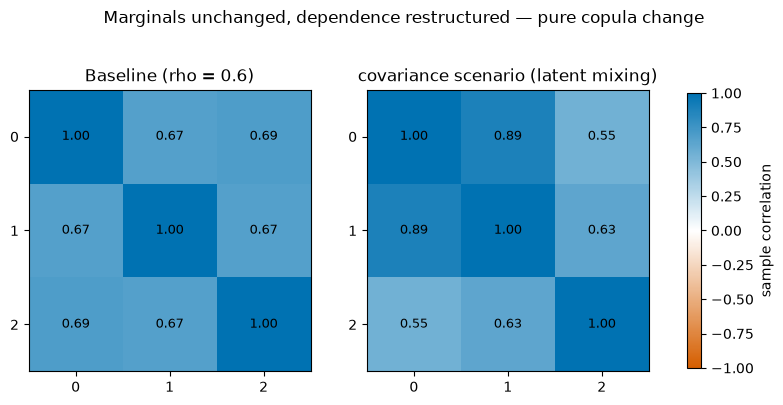

In [ ]:
# code cell 08 : visualizing the covariance scenario's dependence change (Okabe-Ito)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
mats = [
    (np.corrcoef(base, rowvar=False), "Baseline (rho = 0.6)"),
    (np.corrcoef(cand_cov, rowvar=False), "covariance scenario (latent mixing)"),
]
for ax, (mat, title) in zip(axes, mats):
    im = ax.imshow(mat, cmap=DIV_CMAP, vmin=-1.0, vmax=1.0)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=9)
    ax.set_title(title)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
fig.colorbar(im, ax=axes, shrink=0.85, label="sample correlation")
fig.suptitle("Marginals unchanged, dependence restructured — pure copula change", y=1.02)
plt.show()

## 6. Candidate Methods

**Track 1 — univariate (NiriZan's production gate).** `mwu_holm`: per-metric one-sided
Mann–Whitney U ("less"), Holm–Bonferroni across metrics — calling the *real*
`nirizan.metrics.stats` functions, not reimplementations.

**Track 2 — joint / distributional.** Welch-style $T^2$ (unequal covariance),
classical Hotelling $T^2$ (legacy control), Energy distance, MMD (Gaussian kernel,
median-heuristic bandwidth), PERMANOVA, Friedman–Rafsky — all permutation-calibrated
over one shared distance/kernel matrix.

**Track 3 — inter-metric structure.** `covariance` (Frobenius distance between sample
covariances) and `scale` (**new**, added because the review found every
draft-eligible method blind to variance-only degradation): permutation test on
 $\sum_j \big(\log s^2_{y,j} - \log s^2_{x,j}\big)^2$.

Ledoit–Wolf shrinkage variants are evaluated separately at reduced scale (§15): the
per-permutation estimator fit does not vectorize, so a full-grid run would be
dominated by sklearn call overhead rather than statistics.

| Method | Track | Time per call | Space | Dominant cost |
|---|---|---|---|---|
| mwu_holm | 1 | $O(p\,n\log n)$ | $O(p)$ | per-metric rank sort |
| welch_t2 / hotelling_t2 | 2 | $O(R\,n p^2 + p^3)$ | $O(p^2)$ | batched covariance + solve per permutation |
| energy / mmd / permanova / friedman_rafsky | 2 | $O(n^2 p) + O(R\,n^2)$ | $O(n^2)$ | one distance/kernel matrix + MST, reused |
| covariance | 3 | $O(R\,n p^2)$ | $O(p^2)$ | batched covariance per permutation |
| scale | 3 | $O(R\,n p^2)$ | $O(p^2)$ | same, diagonal only |
| *_shrinkage | 2/3 | $O(R\,(n p^2 + p^3))$ + large constant | $O(p^2)$ | per-permutation Ledoit–Wolf fit |

 $R$ = `N_PERMUTATIONS` (149). All permutation statistics are computed through a
vectorized engine whose observed statistic shares the exact code path of every
permutation (identity partition in row 0) — and which is verified against a
loop-based reference implementation in §7 before anything downstream trusts it.

In [ ]:
# code cell 09 : method roster and loop-based reference statistics
METHOD_ORDER = [
    "mwu_holm",
    "welch_t2",
    "hotelling_t2",
    "energy",
    "mmd",
    "permanova",
    "friedman_rafsky",
    "covariance",
    "scale",
]
SHRINKAGE_METHODS = ["welch_t2_shrinkage", "covariance_shrinkage"]
ALL_METHODS = METHOD_ORDER + SHRINKAGE_METHODS
METHOD_IDX = {m: i for i, m in enumerate(METHOD_ORDER)}

ONE_SIDED_METHODS = {"mwu_holm"}  # rejection is already directional
STRUCTURE_METHODS = {"covariance", "scale"}  # direction undefined; detection = escalation


def covariance_matrix(x: np.ndarray, shrinkage: bool = False) -> np.ndarray:
    if shrinkage:
        from sklearn.covariance import LedoitWolf

        return LedoitWolf().fit(x).covariance_
    return np.cov(x, rowvar=False, ddof=1)


def welch_t2_statistic(x: np.ndarray, y: np.ndarray, shrinkage: bool = False) -> float:
    x_mean, y_mean = x.mean(axis=0), y.mean(axis=0)
    sigma_x = covariance_matrix(x, shrinkage)
    sigma_y = covariance_matrix(y, shrinkage)
    nx, ny = len(x), len(y)
    cov = sigma_x / nx + sigma_y / ny
    diff = x_mean - y_mean
    ridge = 1e-10 * max(float(np.trace(cov)), 1.0)
    cov = cov + ridge * np.eye(cov.shape[0])
    return float(diff @ np.linalg.solve(cov, diff))


def hotelling_t2_statistic(x: np.ndarray, y: np.ndarray) -> float:
    x_mean, y_mean = x.mean(axis=0), y.mean(axis=0)
    nx, ny = len(x), len(y)
    pooled = ((nx - 1) * covariance_matrix(x) + (ny - 1) * covariance_matrix(y)) / (nx + ny - 2)
    diff = x_mean - y_mean
    ridge = 1e-10 * max(float(np.trace(pooled)), 1.0)
    pooled = pooled + ridge * np.eye(pooled.shape[0])
    return float((nx * ny / (nx + ny)) * diff @ np.linalg.solve(pooled, diff))


def frobenius_covariance_distance(x: np.ndarray, y: np.ndarray, shrinkage: bool = False) -> float:
    return float(
        np.linalg.norm(covariance_matrix(x, shrinkage) - covariance_matrix(y, shrinkage), ord="fro")
    )


def scale_logvar_statistic(x: np.ndarray, y: np.ndarray) -> float:
    vx = x.var(axis=0, ddof=1)
    vy = y.var(axis=0, ddof=1)
    return float(((np.log(vx + SCALE_EPS) - np.log(vy + SCALE_EPS)) ** 2).sum())


def permutation_test_raw(x, y, statistic_fn, reps, rng):
    """Loop-based permutation test (reference implementation)."""
    observed = statistic_fn(x, y)
    z = np.vstack([x, y])
    n1 = len(x)
    exceed = 0
    for _ in range(reps):
        idx = rng.permutation(len(z))
        if statistic_fn(z[idx[:n1]], z[idx[n1:]]) >= observed:
            exceed += 1
    return observed, (exceed + 1) / (reps + 1)


def mann_whitney_holm_test(x_baseline, y_candidate, alpha=ALPHA):
    """Track 1 — the real production functions: one-sided MWU per metric, Holm across.
    Returns (min p across metrics, any-rejected)."""
    p_values = {}
    for j in range(x_baseline.shape[1]):
        _, p_val = mann_whitney_regression(y_candidate[:, j], x_baseline[:, j], alternative="less")
        p_values[str(j)] = p_val
    rejected = holm_bonferroni(p_values, alpha=alpha)
    return float(min(p_values.values())), bool(any(rejected.values()))


print(
    "Method roster:",
    len(METHOD_ORDER),
    "main-grid methods +",
    len(SHRINKAGE_METHODS),
    "shrinkage variants.",
)

Method roster: 9 main-grid methods + 2 shrinkage variants.


In [ ]:
# code cell 10 : vectorized permutation engine (shared partitions, batched statistics)
def permutation_partition(rng, N, n1, reps, include_identity=True):
    """(reps [+1], N) index array. Row 0 (when included) is the identity partition,
    so the observed statistic goes through the exact same code path as every
    permutation."""
    randoms = np.argsort(rng.random((reps, N)), axis=1)
    if include_identity:
        return np.vstack([np.arange(N)[None, :], randoms])
    return randoms


def group_moments(z, perms, n1):
    """Per-partition group means and ddof=1 covariances, vectorized over rows."""
    px = z[perms[:, :n1]]  # (R, n1, p)
    py = z[perms[:, n1:]]  # (R, n2, p)
    n2 = perms.shape[1] - n1
    mx = px.mean(axis=1)
    my = py.mean(axis=1)
    sxx = np.matmul(np.swapaxes(px, 1, 2), px)  # (R, p, p)
    syy = np.matmul(np.swapaxes(py, 1, 2), py)  # (R, p, p)
    cx = (sxx - n1 * mx[:, :, None] * mx[:, None, :]) / (n1 - 1)
    cy = (syy - n2 * my[:, :, None] * my[:, None, :]) / (n2 - 1)
    return mx, my, cx, cy


def _ridge_term(cov_batch):
    return 1e-10 * np.maximum(np.trace(cov_batch, axis1=1, axis2=2), 1.0)


def welch_from_moments(mx, my, cx, cy, n1, n2, p):
    diff = my - mx
    comb = cx / n1 + cy / n2
    ridge = _ridge_term(comb)
    comb = comb + ridge[:, None, None] * np.eye(p)[None, :, :]
    sol = np.linalg.solve(comb, diff[:, :, None])
    return (diff[:, None, :] @ sol)[:, 0, 0]


def hotelling_from_moments(mx, my, cx, cy, n1, n2, p):
    pooled = ((n1 - 1) * cx + (n2 - 1) * cy) / (n1 + n2 - 2)
    diff = my - mx
    ridge = _ridge_term(pooled)
    pooled = pooled + ridge[:, None, None] * np.eye(p)[None, :, :]
    sol = np.linalg.solve(pooled, diff[:, :, None])
    return (n1 * n2 / (n1 + n2)) * (diff[:, None, :] @ sol)[:, 0, 0]


def frobenius_from_moments(cx, cy):
    return np.sqrt(((cx - cy) ** 2).sum(axis=(1, 2)))


def scale_from_moments(cx, cy):
    vx = np.diagonal(cx, axis1=1, axis2=2)
    vy = np.diagonal(cy, axis1=1, axis2=2)
    return ((np.log(vx + SCALE_EPS) - np.log(vy + SCALE_EPS)) ** 2).sum(axis=1)


def welch_t2_batch(z, perms, n1):
    mx, my, cx, cy = group_moments(z, perms, n1)
    return welch_from_moments(mx, my, cx, cy, n1, perms.shape[1] - n1, z.shape[1])


def hotelling_t2_batch(z, perms, n1):
    mx, my, cx, cy = group_moments(z, perms, n1)
    return hotelling_from_moments(mx, my, cx, cy, n1, perms.shape[1] - n1, z.shape[1])


def covariance_frobenius_batch(z, perms, n1):
    _, _, cx, cy = group_moments(z, perms, n1)
    return frobenius_from_moments(cx, cy)


def scale_logvar_batch(z, perms, n1):
    _, _, cx, cy = group_moments(z, perms, n1)
    return scale_from_moments(cx, cy)


def distance_stats_batch(z, perms, n1):
    """Energy, MMD^2, PERMANOVA pseudo-F, Friedman-Rafsky cross-edge count — all
    calibrated against ONE precomputed distance/kernel matrix and ONE MST, with each
    permutation an O(n^2) reduction over already-computed matrices."""
    N = z.shape[0]
    n2 = N - n1
    D = squareform(pdist(z, metric="euclidean"))
    D2 = D**2
    iu = np.triu_indices(N, 1)
    med = float(np.median(D[iu]))
    bw = med if med > 0.0 else 1.0
    K = np.exp(-D2 / (2.0 * bw**2))
    edges = np.stack(minimum_spanning_tree(D).nonzero(), axis=1)

    R = perms.shape[0]
    B = np.zeros((R, N), dtype=float)
    rows = np.repeat(np.arange(R), n1)
    B[rows, perms[:, :n1].ravel()] = 1.0
    notB = 1.0 - B

    AD = B @ D
    AY_D = notB @ D
    AD2 = B @ D2
    AY_D2 = notB @ D2
    AK = B @ K
    AY_K = notB @ K

    sxx_d = (AD * B).sum(axis=1)
    syy_d = (AY_D * notB).sum(axis=1)
    sxy_d = (AD * notB).sum(axis=1)
    energy = 2.0 * sxy_d / (n1 * n2) - sxx_d / (n1**2) - syy_d / (n2**2)

    kxx = (AK * B).sum(axis=1) - B.sum(axis=1)
    kyy = (AY_K * notB).sum(axis=1) - notB.sum(axis=1)
    kxy = (AK * notB).sum(axis=1)
    mmd2 = kxx / (n1 * (n1 - 1)) + kyy / (n2 * (n2 - 1)) - 2.0 * kxy / (n1 * n2)

    ssw = (AD2 * B).sum(axis=1) / (2 * n1) + (AY_D2 * notB).sum(axis=1) / (2 * n2)
    sst = D2[iu].sum() / N
    permanova = (sst - ssw) * (N - 2) / ssw

    Bb = B > 0.5
    cross = (Bb[:, edges[:, 0]] != Bb[:, edges[:, 1]]).sum(axis=1).astype(float)
    return {"energy": energy, "mmd": mmd2, "permanova": permanova, "friedman_rafsky": cross}


def distance_stats_loop(z, perms, n1):
    """Reference loop implementation of the four distance statistics."""
    N = z.shape[0]
    D = squareform(pdist(z, metric="euclidean"))
    D2 = D**2
    iu = np.triu_indices(N, 1)
    med = float(np.median(D[iu]))
    bw = med if med > 0.0 else 1.0
    K = np.exp(-D2 / (2.0 * bw**2))
    edges = np.stack(minimum_spanning_tree(D).nonzero(), axis=1)
    out = {"energy": [], "mmd": [], "permanova": [], "friedman_rafsky": []}
    for r in range(perms.shape[0]):
        gx, gy = perms[r, :n1], perms[r, n1:]
        dxx = D[np.ix_(gx, gx)].sum() / (len(gx) ** 2)
        dyy = D[np.ix_(gy, gy)].sum() / (len(gy) ** 2)
        dxy = D[np.ix_(gx, gy)].mean()
        out["energy"].append(2.0 * dxy - dxx - dyy)
        kxx = (K[np.ix_(gx, gx)].sum() - len(gx)) / (len(gx) * (len(gx) - 1))
        kyy = (K[np.ix_(gy, gy)].sum() - len(gy)) / (len(gy) * (len(gy) - 1))
        kxy = K[np.ix_(gx, gy)].mean()
        out["mmd"].append(kxx + kyy - 2.0 * kxy)
        ssw = D2[np.ix_(gx, gx)].sum() / (2 * len(gx)) + D2[np.ix_(gy, gy)].sum() / (2 * len(gy))
        sst = D2[iu].sum() / N
        out["permanova"].append((sst - ssw) * (N - 2) / ssw)
        in_x = np.zeros(N, dtype=bool)
        in_x[gx] = True
        out["friedman_rafsky"].append(float((in_x[edges[:, 0]] != in_x[edges[:, 1]]).sum()))
    return {k: np.array(v) for k, v in out.items()}


def evaluate_pair(x, y, rng):
    """Run every main-grid method once on one (baseline=x, candidate=y) pair.

    One shared partition set feeds all statistics. Returns (pvals, rejects, dsign)
    in METHOD_ORDER; dsign is the sign of the summed mean difference used for
    direction recovery downstream.
    """
    n1, p_dim = x.shape
    n2 = y.shape[0]
    z = np.vstack([x, y])
    perms = permutation_partition(rng, n1 + n2, n1, N_PERMUTATIONS)

    min_p, t1_reject = mann_whitney_holm_test(x, y)

    mx, my, cx, cy = group_moments(z, perms, n1)
    welch = welch_from_moments(mx, my, cx, cy, n1, n2, p_dim)
    hotelling = hotelling_from_moments(mx, my, cx, cy, n1, n2, p_dim)
    covf = frobenius_from_moments(cx, cy)
    scale = scale_from_moments(cx, cy)
    dist = distance_stats_batch(z, perms, n1)

    def _p(vec, evidence="greater"):
        obs = vec[0]
        exceed = int((vec[1:] <= obs).sum()) if evidence == "less" else int((vec[1:] >= obs).sum())
        return (exceed + 1) / len(vec)

    pvals = np.array(
        [
            min_p,
            _p(welch),
            _p(hotelling),
            _p(dist["energy"]),
            _p(dist["mmd"]),
            _p(dist["permanova"]),
            _p(dist["friedman_rafsky"], evidence="less"),
            _p(covf),
            _p(scale),
        ]
    )
    rejects = np.array(
        [t1_reject] + [pvals[i] <= ALPHA for i in range(1, len(METHOD_ORDER))], dtype=bool
    )
    dsign = float(np.sign((y.mean(axis=0) - x.mean(axis=0)).sum()))
    return pvals, rejects, dsign


print("Vectorized permutation engine defined (shared partitions, identity row 0).")

Vectorized permutation engine defined (shared partitions, identity row 0).


## 7. Engine Verification

Every statistic above is hand-vectorized, so before anything downstream trusts it I
check the vectorized engine against the loop-based reference on the **same**
permutation index arrays — observed row included — and require agreement to floating
tolerance. A mismatch here would silently corrupt every p-value in the notebook.

In [ ]:
# code cell 11 : loop vs vectorized equality on identical partitions (table output)
verify_rng = np.random.default_rng(2026)
x_v = make_baseline(30, 4, 0.5, verify_rng)
y_v = make_candidate(30, 4, 0.5, scn["location"], verify_rng)
z_v = np.vstack([x_v, y_v])
perms_v = permutation_partition(verify_rng, 60, 30, 40, include_identity=False)
perms_full = np.vstack([np.arange(60)[None, :], perms_v])

loop_stats = {
    "welch_t2": np.array([welch_t2_statistic(z_v[pr[:30]], z_v[pr[30:]]) for pr in perms_full]),
    "hotelling_t2": np.array(
        [hotelling_t2_statistic(z_v[pr[:30]], z_v[pr[30:]]) for pr in perms_full]
    ),
    "covariance": np.array(
        [frobenius_covariance_distance(z_v[pr[:30]], z_v[pr[30:]]) for pr in perms_full]
    ),
    "scale": np.array([scale_logvar_statistic(z_v[pr[:30]], z_v[pr[30:]]) for pr in perms_full]),
}
loop_stats.update(distance_stats_loop(z_v, perms_full, 30))

dist_vec = distance_stats_batch(z_v, perms_full, 30)
vec_stats = {
    "welch_t2": welch_t2_batch(z_v, perms_full, 30),
    "hotelling_t2": hotelling_t2_batch(z_v, perms_full, 30),
    "covariance": covariance_frobenius_batch(z_v, perms_full, 30),
    "scale": scale_logvar_batch(z_v, perms_full, 30),
    **dist_vec,
}

rows = []
for name in [
    "welch_t2",
    "hotelling_t2",
    "covariance",
    "scale",
    "energy",
    "mmd",
    "permanova",
    "friedman_rafsky",
]:
    lv = np.asarray(loop_stats[name], dtype=float)
    vv = np.asarray(vec_stats[name], dtype=float)
    scale_ref = max(float(np.abs(vv).max()), 1e-12)
    rows.append(
        {
            "statistic": name,
            "max_abs_diff": float(np.abs(lv - vv).max()),
            "relative_to_scale": float(np.abs(lv - vv).max() / scale_ref),
        }
    )
verify_df = pd.DataFrame(rows)
display(verify_df)

worst = float(verify_df["max_abs_diff"].max())
assert worst < 1e-6, f"vectorized engine disagrees with loop reference (max diff {worst:.3e})"
print(
    f"\nAll 8 statistics agree between loop and vectorized engines "
    f"(worst abs diff {worst:.2e}); observed row included in the comparison."
)

,statistic,max_abs_diff,relative_to_scale
0,welch_t2,2.486900e-14,1.429184e-15
1,hotelling_t2,1.065814e-14,6.125076e-16
2,covariance,3.053113e-16,2.389045e-15
3,scale,2.553513e-15,3.706755e-15
4,energy,6.661338e-16,3.711611e-15
5,mmd,4.440892e-16,4.947939e-15
6,permanova,1.998401e-14,3.281600e-15
7,friedman_rafsky,0.000000e+00,0.000000e+00



All 8 statistics agree between loop and vectorized engines (worst abs diff 2.49e-14); observed row included in the comparison.


## 8. Unified Interface and Sanity Pass

Every candidate returns the same `TestResult` record. A quick pass on two independent
i.i.d. baseline samples confirms nothing throws, all p-values are valid, and gives a
first look at per-call cost. This is not a statistical claim about false-alarm rates —
that is §11 — just a smoke test.

In [ ]:
# code cell 12 : run_test dispatcher and i.i.d. sanity pass (table output)
@dataclass(frozen=True)
class TestResult:
    method: str
    statistic: float
    p_value: float
    runtime_seconds: float
    peak_memory_bytes: int


def _batch_p(x, y, rng, batch_fn, reps=N_PERMUTATIONS, evidence="greater"):
    z = np.vstack([x, y])
    perms = permutation_partition(rng, len(z), len(x), reps)
    vec = batch_fn(z, perms, len(x))
    obs = vec[0]
    exceed = int((vec[1:] <= obs).sum()) if evidence == "less" else int((vec[1:] >= obs).sum())
    return float(obs), (exceed + 1) / (reps + 1)


def run_test(method, x, y, rng, measure_memory=False, reps=N_PERMUTATIONS):
    """x = baseline, y = candidate throughout. measure_memory=True wraps the call in
    tracemalloc (kept off inside the Monte Carlo grid: its bookkeeping overhead
    measures kernel heap pressure as much as the candidate)."""
    if measure_memory:
        tracemalloc.start()
    start = perf_counter()
    failed = False
    try:
        if method == "mwu_holm":
            min_p, rejected = mann_whitney_holm_test(x, y)
            statistic, p_value = min_p, (0.0 if rejected else 1.0)
        elif method == "welch_t2":
            statistic, p_value = _batch_p(x, y, rng, welch_t2_batch, reps)
        elif method == "hotelling_t2":
            statistic, p_value = _batch_p(x, y, rng, hotelling_t2_batch, reps)
        elif method == "covariance":
            statistic, p_value = _batch_p(x, y, rng, covariance_frobenius_batch, reps)
        elif method == "scale":
            statistic, p_value = _batch_p(x, y, rng, scale_logvar_batch, reps)
        elif method in ("energy", "mmd", "permanova", "friedman_rafsky"):
            z = np.vstack([x, y])
            perms = permutation_partition(rng, len(z), len(x), reps)
            stats = distance_stats_batch(z, perms, len(x))
            obs = stats[method][0]
            if method == "friedman_rafsky":
                exceed = int((stats[method][1:] <= obs).sum())
            else:
                exceed = int((stats[method][1:] >= obs).sum())
            statistic, p_value = float(obs), (exceed + 1) / (reps + 1)
        elif method == "welch_t2_shrinkage":
            fn = lambda a, b: welch_t2_statistic(a, b, shrinkage=True)
            statistic, p_value = permutation_test_raw(x, y, fn, reps, rng)
        elif method == "covariance_shrinkage":
            fn = lambda a, b: frobenius_covariance_distance(a, b, shrinkage=True)
            statistic, p_value = permutation_test_raw(x, y, fn, reps, rng)
        else:
            raise ValueError(f"Unknown method: {method}")
    except (np.linalg.LinAlgError, ValueError):
        statistic, p_value, failed = float("nan"), 1.0, True
    runtime = perf_counter() - start
    peak = 0
    if measure_memory:
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
    if failed:
        p_value = 1.0  # a numerically failed test must never count as a detection
    return TestResult(method, float(statistic), float(p_value), runtime, int(peak))


sanity_rng = np.random.default_rng(SEED)
x_s = make_baseline(30, 4, 0.4, sanity_rng)
y_s = make_candidate(30, 4, 0.4, NULL_SCENARIO, sanity_rng)

rows = []
for method in ALL_METHODS:
    res = run_test(method, x_s, y_s, sanity_rng, measure_memory=True)
    rows.append(res.__dict__)
    assert 0.0 <= res.p_value <= 1.0 and res.runtime_seconds >= 0.0
sanity_df = pd.DataFrame(rows)
sanity_df

,method,statistic,p_value,runtime_seconds,peak_memory_bytes
0,mwu_holm,0.028730,1.000000,0.006855,19170
1,welch_t2,7.495549,0.146667,0.001218,494427
2,hotelling_t2,7.495549,0.120000,0.000743,494048
3,energy,0.063863,0.166667,0.003130,902787
4,mmd,0.013368,0.153333,0.003515,902653
5,permanova,1.376848,0.226667,0.003474,902541
6,friedman_rafsky,30.000000,0.553333,0.002757,902373
7,covariance,0.087093,0.233333,0.000588,494048
8,scale,0.438988,0.153333,0.000534,494048
9,welch_t2_shrinkage,6.703610,0.153333,2.775064,18557939


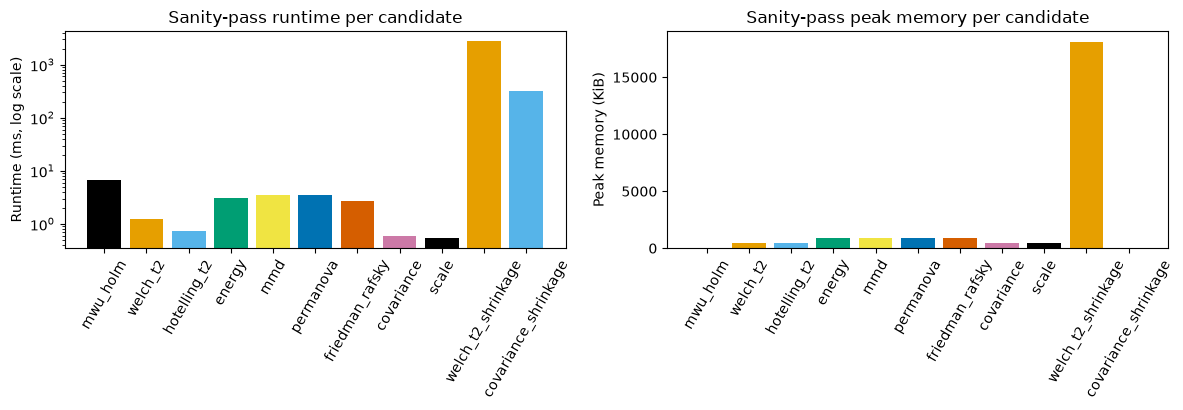

In [ ]:
# code cell 13 : sanity-pass runtime and memory (Okabe-Ito)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
colors = [OKABE_ITO_CYCLE[i % len(OKABE_ITO_CYCLE)] for i in range(len(sanity_df))]
axes[0].bar(sanity_df["method"], sanity_df["runtime_seconds"] * 1000.0, color=colors)
axes[0].set_yscale("log")
axes[0].set_ylabel("Runtime (ms, log scale)")
axes[0].set_title("Sanity-pass runtime per candidate")
axes[1].bar(sanity_df["method"], sanity_df["peak_memory_bytes"] / 1024.0, color=colors)
axes[1].set_ylabel("Peak memory (KiB)")
axes[1].set_title("Sanity-pass peak memory per candidate")
for ax in axes:
    ax.tick_params(axis="x", rotation=60)
fig.tight_layout()
plt.show()

## 9. Validity and Robustness Checks

Before trusting any Monte Carlo estimate I check each candidate degrades gracefully —
or fails loudly and safely — under conditions that occur in NiriZan's production score
distributions: malformed input, zero-variance (saturated) metrics, $p > n$ singular
covariance, unequal baseline/candidate sample sizes, and pile-up against the $[0,1]$ ceiling. The boundary-pile-up check runs the full `N_MONTE_CARLO` repetitions because
it is itself a false-alarm-rate claim, and is gated by the same one-sided binomial
test as §11.

In [ ]:
# code cell 14 : 9.1 NaN / invalid input rejection (text output)
invalid_cases = {
    "contains_nan": np.array([0.5, np.nan, 0.2]),
    "contains_inf": np.array([0.5, np.inf, 0.2]),
    "above_one": np.array([0.5, 1.2, 0.2]),
    "below_zero": np.array([0.5, -0.1, 0.2]),
    "empty": np.array([]),
}
invalid_input_report = {}
for name, arr in invalid_cases.items():
    try:
        validate_scores(arr)
        invalid_input_report[name] = "NOT REJECTED (unexpected)"
    except ValueError as exc:
        invalid_input_report[name] = f"rejected: {exc}"
for name, outcome in invalid_input_report.items():
    print(f"{name:15s} -> {outcome}")
assert all("rejected" in outcome for outcome in invalid_input_report.values())
print(
    "\nnirizan.metrics.stats.validate_scores (the production boundary) rejects every",
    "malformed input tried.",
)

contains_nan    -> rejected: Scores contain non-finite values (NaN/Inf).
contains_inf    -> rejected: Scores contain non-finite values (NaN/Inf).
above_one       -> rejected: NiriZan metric scores must be normalized to [0, 1].
below_zero      -> rejected: NiriZan metric scores must be normalized to [0, 1].
empty           -> rejected: Score distribution is empty.

nirizan.metrics.stats.validate_scores (the production boundary) rejects every malformed input tried.


### 9.2 Constant / zero-variance metric column

In [ ]:
# code cell 15 : zero-variance column across all candidates (table output)
const_rng = np.random.default_rng(SEED)
x_const = np.column_stack([np.full(30, 0.8), const_rng.uniform(0.5, 0.9, size=30)])
y_const = np.column_stack([np.full(30, 0.8), const_rng.uniform(0.4, 0.8, size=30)])

const_rows = []
for method in ALL_METHODS:
    res = run_test(method, x_const, y_const, const_rng)
    const_rows.append(
        {
            "method": method,
            "p_value": round(res.p_value, 4),
            "numerically_valid": not np.isnan(res.statistic),
        }
    )
const_df = pd.DataFrame(const_rows)
const_df

,method,p_value,numerically_valid
0,mwu_holm,0.0000,True
1,welch_t2,0.0133,True
2,hotelling_t2,0.0067,True
3,energy,0.0133,True
4,mmd,0.0267,True
5,permanova,0.0067,True
6,friedman_rafsky,0.2800,True
7,covariance,0.6267,True
8,scale,0.6000,True
9,welch_t2_shrinkage,0.0067,True


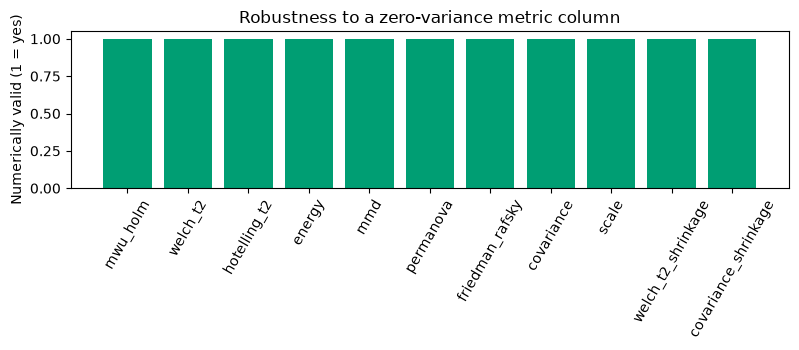

In [ ]:
# code cell 16 : zero-variance validity (Okabe-Ito)
fig, ax = plt.subplots(figsize=(8, 3.6))
colors = [
    OKABE_ITO["bluish_green"] if v else OKABE_ITO["vermillion"]
    for v in const_df["numerically_valid"]
]
ax.bar(const_df["method"], const_df["numerically_valid"].astype(int), color=colors)
ax.set_ylabel("Numerically valid (1 = yes)")
ax.set_title("Robustness to a zero-variance metric column")
ax.tick_params(axis="x", rotation=60)
fig.tight_layout()
plt.show()

### 9.3 High-dimensional / singular covariance ($n < p$)

The ridge term in the Welch and Hotelling statistics exists for this case; I check it
prevents a `LinAlgError` rather than assuming it does.

In [ ]:
# code cell 17 : n=10, p=25 singular-covariance stress test (table output)
singular_rng = np.random.default_rng(SEED)
x_sing = make_baseline(10, 25, 0.3, singular_rng)
y_sing = make_candidate(10, 25, 0.3, scn["location"], singular_rng)

singular_rows = []
for method in ALL_METHODS:
    res = run_test(method, x_sing, y_sing, singular_rng)
    singular_rows.append(
        {
            "method": method,
            "p_value": round(res.p_value, 4),
            "numerically_valid": not np.isnan(res.statistic),
        }
    )
singular_df = pd.DataFrame(singular_rows)
singular_df

,method,p_value,numerically_valid
0,mwu_holm,1.0000,True
1,welch_t2,0.0400,True
2,hotelling_t2,0.0267,True
3,energy,0.0067,True
4,mmd,0.0133,True
5,permanova,0.0067,True
6,friedman_rafsky,0.0133,True
7,covariance,0.9400,True
8,scale,0.9667,True
9,welch_t2_shrinkage,0.0267,True


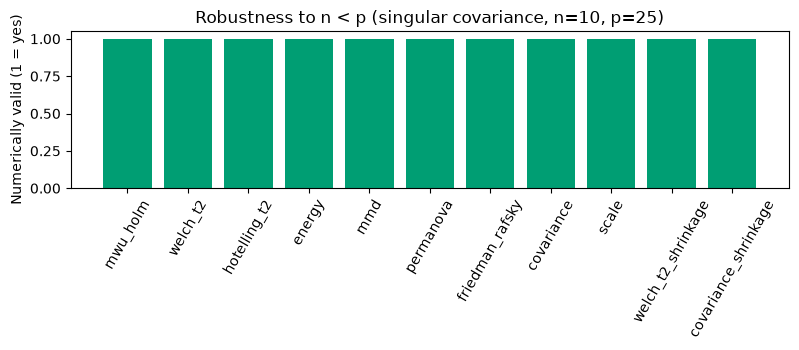

In [ ]:
# code cell 18 : n < p validity (Okabe-Ito)
fig, ax = plt.subplots(figsize=(8, 3.6))
colors = [
    OKABE_ITO["bluish_green"] if v else OKABE_ITO["vermillion"]
    for v in singular_df["numerically_valid"]
]
ax.bar(singular_df["method"], singular_df["numerically_valid"].astype(int), color=colors)
ax.set_ylabel("Numerically valid (1 = yes)")
ax.set_title("Robustness to n < p (singular covariance, n=10, p=25)")
ax.tick_params(axis="x", rotation=60)
fig.tight_layout()
plt.show()

### 9.4 Unequal baseline / candidate sample sizes (3:1)

In [ ]:
# code cell 19 : n_x=90 vs n_y=30 under a true location shift (table output)
unequal_rng = np.random.default_rng(SEED)
x_un = make_baseline(90, 4, 0.4, unequal_rng)
y_un = make_candidate(30, 4, 0.4, scn["location"], unequal_rng)

unequal_rows = []
for method in ALL_METHODS:
    res = run_test(method, x_un, y_un, unequal_rng)
    unequal_rows.append(
        {
            "method": method,
            "p_value": round(res.p_value, 4),
            "rejected_at_alpha": res.p_value <= ALPHA,
        }
    )
unequal_df = pd.DataFrame(unequal_rows)
unequal_df

,method,p_value,rejected_at_alpha
0,mwu_holm,0.0000,True
1,welch_t2,0.0067,True
2,hotelling_t2,0.0067,True
3,energy,0.0067,True
4,mmd,0.0067,True
5,permanova,0.0067,True
6,friedman_rafsky,0.0267,True
7,covariance,0.8267,False
8,scale,0.6333,False
9,welch_t2_shrinkage,0.0067,True


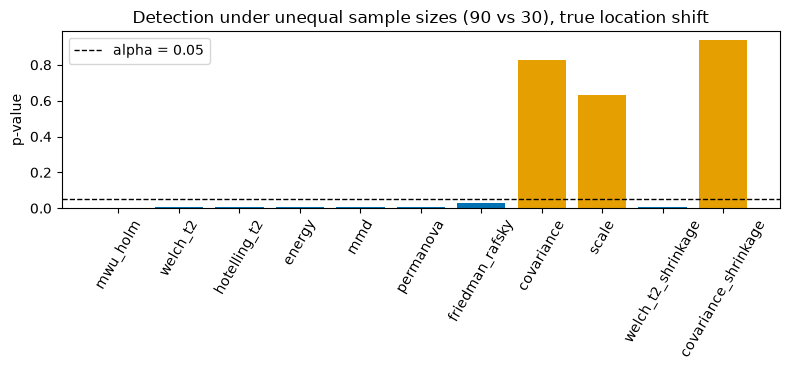

In [ ]:
# code cell 20 : detection under unequal sample sizes (Okabe-Ito)
fig, ax = plt.subplots(figsize=(8, 3.8))
colors = [OKABE_ITO["blue"] if v else OKABE_ITO["orange"] for v in unequal_df["rejected_at_alpha"]]
ax.bar(unequal_df["method"], unequal_df["p_value"], color=colors)
ax.axhline(ALPHA, color=OKABE_ITO["black"], linestyle="--", linewidth=1, label=f"alpha = {ALPHA}")
ax.set_ylabel("p-value")
ax.set_title("Detection under unequal sample sizes (90 vs 30), true location shift")
ax.tick_params(axis="x", rotation=60)
ax.legend()
fig.tight_layout()
plt.show()

### 9.5 Boundary pile-up near 1.0 (false-alarm check under H0)

NiriZan scores routinely saturate near the ceiling. I measure the false-alarm rate of
each main-grid method on Beta(12, 1.5) samples — with no real regression — at full
`N_MONTE_CARLO` repetitions, gated by the same one-sided binomial test used in §11.

In [ ]:
# code cell 21 : FAR under boundary pile-up at full Monte Carlo scale (table output)
def make_boundary_heavy(n, p, rng):
    return rng.beta(a=12.0, b=1.5, size=(n, p))


boundary_rng = np.random.default_rng(SEED)
boundary_rejections = {m: 0 for m in METHOD_ORDER}
for _ in range(N_MONTE_CARLO):
    xb = make_boundary_heavy(60, 4, boundary_rng)
    yb = make_boundary_heavy(60, 4, boundary_rng)
    for method in METHOD_ORDER:
        res = run_test(method, xb, yb, boundary_rng)
        boundary_rejections[method] += int(res.p_value <= ALPHA)

boundary_far_df = pd.DataFrame(
    {
        "method": list(boundary_rejections),
        "FAR_under_boundary_pileup": [v / N_MONTE_CARLO for v in boundary_rejections.values()],
    }
)
boundary_far_df["binom_p_vs_limit"] = [
    float(binomtest(v, N_MONTE_CARLO, FAR_LIMIT, alternative="greater").pvalue)
    for v in boundary_rejections.values()
]
boundary_far_df["exceeds_limit_significantly"] = boundary_far_df["binom_p_vs_limit"] < ALPHA
boundary_far_df.sort_values("FAR_under_boundary_pileup")

,method,FAR_under_boundary_pileup,binom_p_vs_limit,exceeds_limit_significantly
1,welch_t2,0.037333,0.999609,False
7,covariance,0.040667,0.992906,False
2,hotelling_t2,0.041000,0.990939,False
6,friedman_rafsky,0.041333,0.988516,False
5,permanova,0.042000,0.981974,False
0,mwu_holm,0.044333,0.930770,False
3,energy,0.044667,0.918427,False
4,mmd,0.044667,0.918427,False
8,scale,0.049000,0.610897,False


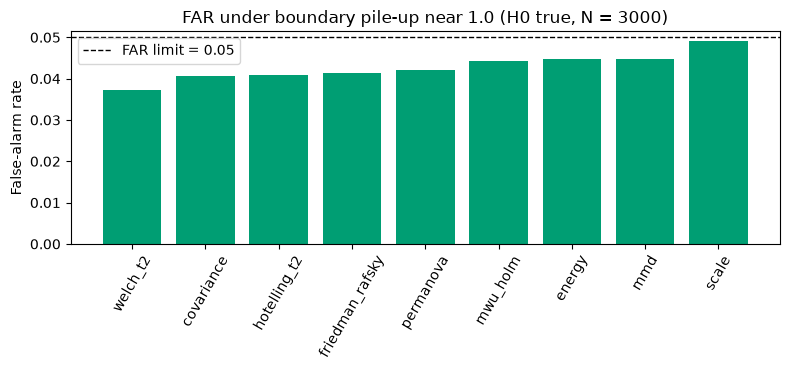

In [ ]:
# code cell 22 : boundary pile-up FAR (Okabe-Ito)
fig, ax = plt.subplots(figsize=(8, 3.8))
order = boundary_far_df.sort_values("FAR_under_boundary_pileup")
colors = [
    OKABE_ITO["vermillion"] if f else OKABE_ITO["bluish_green"]
    for f in order["exceeds_limit_significantly"]
]
ax.bar(order["method"], order["FAR_under_boundary_pileup"], color=colors)
ax.axhline(
    FAR_LIMIT,
    color=OKABE_ITO["black"],
    linestyle="--",
    linewidth=1,
    label=f"FAR limit = {FAR_LIMIT}",
)
ax.set_ylabel("False-alarm rate")
ax.set_title(f"FAR under boundary pile-up near 1.0 (H0 true, N = {N_MONTE_CARLO})")
ax.tick_params(axis="x", rotation=60)
ax.legend()
fig.tight_layout()
plt.show()

## 10. Monte Carlo Benchmark Design

Full grid: every scenario × sample size $n \in \{15, 30, 60\}$ × dimensionality
 $p \in \{3, 10\}$ × equicorrelation $\rho \in \{0.0, 0.6\}$ (12 configurations) ×
`N_MONTE_CARLO` repetitions (500 hosted / 3000 local) × 9 main-grid methods.

**Storage-first architecture.** The expensive loop runs once and stores, per
(scenario, configuration) block, the per-repetition p-values, reject flags, and
mean-direction sign for every method. Everything downstream — the disaggregated FAR
gate, per-scenario power, directional accounting, stability, and the §17 combination
rules — is a post-hoc computation on those stored arrays. This is what makes
re-analyzing under a different gate or combination rule free, and it is what the
earlier draft's evaluate-and-aggregate-immediately loop could not do.

Reproducibility: each (scenario, configuration) block draws from its own
`default_rng([SEED, scenario_index, config_index])` stream, so any block can be
recomputed independently of host or iteration order. If `N_MONTE_CARLO` was overridden
below ~100, treat everything downstream as a smoke run.

In [ ]:
# code cell 23 : grid declaration and runtime calibration (text output)
SAMPLE_SIZES = (15, 30, 60)
DIMENSIONS = (3, 10)
CORRELATIONS = (0.0, 0.6)
GRID = [(n, p_dim, rho) for n in SAMPLE_SIZES for p_dim in DIMENSIONS for rho in CORRELATIONS]
N_CONFIGS = len(GRID)

calib_rng = np.random.default_rng(SEED)
costs = []
for n, p_dim, rho in [(15, 3, 0.0), (60, 10, 0.6)]:
    xc = make_baseline(n, p_dim, rho, calib_rng)
    yc = make_candidate(n, p_dim, rho, scn["location"], calib_rng)
    t0 = perf_counter()
    for _ in range(5):
        evaluate_pair(xc, yc, calib_rng)
    costs.append((perf_counter() - t0) / 5)

total_reps = len(SCENARIOS) * N_CONFIGS * N_MONTE_CARLO
print(f"Grid: {len(SCENARIOS)} scenarios x {N_CONFIGS} configurations x {N_MONTE_CARLO} reps")
print(f"     = {total_reps} rep-evaluations, all 9 methods computed per rep.")
print(
    f"Calibrated per-rep cost: {min(costs) * 1000:.1f}-{max(costs) * 1000:.1f} ms "
    f"-> estimated grid runtime ~{total_reps * min(costs) / 60:.1f}-{total_reps * max(costs) / 60:.1f} "
    f"minutes (upper bound assumes the heaviest configuration throughout)."
)
if N_MONTE_CARLO < 100:
    print(
        "WARNING: N_MONTE_CARLO is overridden small; treat all downstream results as a smoke run."
    )

Grid: 9 scenarios x 12 configurations x 3000 reps
     = 324000 rep-evaluations, all 9 methods computed per rep.
Calibrated per-rep cost: 2.7-8.9 ms -> estimated grid runtime ~14.7-47.9 minutes (upper bound assumes the heaviest configuration throughout).


In [ ]:
# code cell 24 : the Monte Carlo loop (single heavy pass; progress printed)
mc_results: dict[tuple, dict] = {}
t_start = perf_counter()
reps_done = 0

for s_idx, scenario in enumerate(SCENARIOS):
    for c_idx, (n, p_dim, rho) in enumerate(GRID):
        data_rng = np.random.default_rng([SEED, s_idx, c_idx])
        perm_rng = np.random.default_rng([SEED, s_idx, c_idx, 1])
        pvals = np.empty((N_MONTE_CARLO, len(METHOD_ORDER)))
        rejects = np.empty((N_MONTE_CARLO, len(METHOD_ORDER)), dtype=bool)
        dsign = np.empty(N_MONTE_CARLO)
        for rep in range(N_MONTE_CARLO):
            x = make_baseline(n, p_dim, rho, data_rng)
            y = make_candidate(n, p_dim, rho, scenario, data_rng)
            pv, rj, ds = evaluate_pair(x, y, perm_rng)
            pvals[rep], rejects[rep], dsign[rep] = pv, rj, ds
        mc_results[(scenario.name, n, p_dim, rho)] = {
            "pvals": pvals,
            "rejects": rejects,
            "dsign": dsign,
            "n": n,
            "p": p_dim,
            "rho": rho,
            "trials": N_MONTE_CARLO,
        }
        reps_done += N_MONTE_CARLO
        elapsed = perf_counter() - t_start
        eta = elapsed / reps_done * (total_reps - reps_done)
        print(
            f"[{scenario.name:>12s}] n={n:3d} p={p_dim:3d} rho={rho:.1f} | "
            f"{reps_done:7d}/{total_reps} reps | elapsed {elapsed:7.1f}s | eta {eta:7.1f}s"
        )

assert all(np.all((blk["pvals"] >= 0) & (blk["pvals"] <= 1)) for blk in mc_results.values())
approx_mb = (
    sum(b["pvals"].nbytes + b["rejects"].nbytes + b["dsign"].nbytes for b in mc_results.values())
    / 1e6
)
print(
    f"\nMonte Carlo complete: {len(mc_results)} (scenario x config) blocks, "
    f"{total_reps} rep-evaluations in {(perf_counter() - t_start) / 60:.1f} min; "
    f"stored records ~{approx_mb:.1f} MB."
)

[          H0] n= 15 p=  3 rho=0.0 |    3000/324000 reps | elapsed     6.6s | eta   705.8s
[          H0] n= 15 p=  3 rho=0.6 |    6000/324000 reps | elapsed    13.3s | eta   706.1s
[          H0] n= 15 p= 10 rho=0.0 |    9000/324000 reps | elapsed    28.0s | eta   978.6s
[          H0] n= 15 p= 10 rho=0.6 |   12000/324000 reps | elapsed    42.6s | eta  1106.7s
[          H0] n= 30 p=  3 rho=0.0 |   15000/324000 reps | elapsed    51.0s | eta  1051.3s
[          H0] n= 30 p=  3 rho=0.6 |   18000/324000 reps | elapsed    59.4s | eta  1009.9s
[          H0] n= 30 p= 10 rho=0.0 |   21000/324000 reps | elapsed    75.8s | eta  1093.8s
[          H0] n= 30 p= 10 rho=0.6 |   24000/324000 reps | elapsed    92.3s | eta  1154.0s
[          H0] n= 60 p=  3 rho=0.0 |   27000/324000 reps | elapsed   105.0s | eta  1155.5s
[          H0] n= 60 p=  3 rho=0.6 |   30000/324000 reps | elapsed   117.8s | eta  1154.9s
[          H0] n= 60 p= 10 rho=0.0 |   33000/324000 reps | elapsed   139.4s | eta  1228.9s

## 11. False-Alarm Rates and the Disaggregated Eligibility Gate

This is the section the whole notebook depends on. For every method I report:

- the **per-configuration FAR table** (12 configurations, Wilson 95% intervals, raw
  and Holm-corrected one-sided binomial tests against the 5% limit),
- the **eligibility decision** under the §3 gate — worst configuration, not the average,
- a **direct re-test of the earlier draft's reported spike** (`covariance` method at
  n=15, ρ=0), which at N=20 was a 2/20 count that a true 5% rate produces ~26% of the
  time; at this $N$ it is either confirmed or resolved as noise,
- the **detection sensitivity** of the gate itself, so the reader knows which true
  per-configuration violations this procedure can catch at this host's $N$.

In [ ]:
# code cell 25 : FAR tables, eligibility, spike re-test, gate sensitivity
from scipy.stats import binom

Z95 = 1.959963984540054


def wilson_ci(k, n, z=Z95):
    phat = k / n
    denom = 1.0 + z * z / n
    center = (phat + z * z / (2.0 * n)) / denom
    half = (z / denom) * np.sqrt(phat * (1.0 - phat) / n + z * z / (4.0 * n * n))
    return center - half, center + half


far_rows, far_summary_rows = [], []
h0_blocks = [mc_results[("H0", *cfg)] for cfg in GRID]

for method in METHOD_ORDER:
    midx = METHOD_IDX[method]
    counts = [int(blk["rejects"][:, midx].sum()) for blk in h0_blocks]
    raw_ps = [
        float(binomtest(k, N_MONTE_CARLO, FAR_LIMIT, alternative="greater").pvalue) for k in counts
    ]
    holm = holm_bonferroni({f"cfg{i}": p for i, p in enumerate(raw_ps)}, alpha=ALPHA)
    flags = [bool(holm[f"cfg{i}"]) for i in range(N_CONFIGS)]
    agg_k, agg_n = sum(counts), N_MONTE_CARLO * N_CONFIGS
    agg_p = float(binomtest(agg_k, agg_n, FAR_LIMIT, alternative="greater").pvalue)
    worst = int(np.argmax(counts))
    lo_w, hi_w = wilson_ci(counts[worst], N_MONTE_CARLO)
    far_summary_rows.append(
        {
            "method": method,
            "aggregate_far": agg_k / agg_n,
            "aggregate_binom_p": agg_p,
            "worst_config": f"n{GRID[worst][0]},p{GRID[worst][1]},r{GRID[worst][2]}",
            "worst_config_far": counts[worst] / N_MONTE_CARLO,
            "worst_wilson_lo": lo_w,
            "worst_wilson_hi": hi_w,
            "configs_flagged": int(sum(flags)),
            "eligible": (not any(flags)) and (agg_p >= ALPHA),
        }
    )
    for i, cfg in enumerate(GRID):
        lo_i, hi_i = wilson_ci(counts[i], N_MONTE_CARLO)
        far_rows.append(
            {
                "method": method,
                "n": cfg[0],
                "p": cfg[1],
                "rho": cfg[2],
                "rejections": counts[i],
                "far": counts[i] / N_MONTE_CARLO,
                "wilson_lo": lo_i,
                "wilson_hi": hi_i,
                "binom_p": raw_ps[i],
                "holm_flag": flags[i],
            }
        )

far_df = pd.DataFrame(far_rows)
far_summary = pd.DataFrame(far_summary_rows)

print("=" * 84)
print("DISAGGREGATED ELIGIBILITY — a method passes only if NO configuration shows")
print("significant FAR excess after Holm correction across its 12 config tests, and")
print("the aggregate test does not flag either.")
print("=" * 84)
for _, r in far_summary.iterrows():
    print(
        f"{r['method']:>16s}: agg {r['aggregate_far'] * 100:5.2f}% | worst {r['worst_config']:>12s} "
        f"at {r['worst_config_far'] * 100:5.2f}% | flagged cfgs {r['configs_flagged']:2d} | "
        f"eligible: {r['eligible']}"
    )
display(far_summary)

print("\nPer-configuration detail (all methods):")
display(far_df)

print("\n--- Re-test of the earlier draft's reported spike: covariance method, n=15, rho=0.0 ---")
spike = far_df[(far_df["method"] == "covariance") & (far_df["n"] == 15) & (far_df["rho"] == 0.0)]
for _, r in spike.iterrows():
    verdict = (
        "REPLICATES (significant excess beyond noise)"
        if r["holm_flag"]
        else "does not replicate beyond Monte Carlo noise at this N"
    )
    print(
        f"  p={int(r['p']):2d}: FAR={r['far'] * 100:5.2f}%  "
        f"(Wilson 95% CI {r['wilson_lo'] * 100:.2f}-{r['wilson_hi'] * 100:.2f}%), "
        f"binom p={r['binom_p']:.4f} -> {verdict}"
    )

# Gate sensitivity: what true per-config FAR can this procedure catch?
ks = np.arange(0, N_MONTE_CARLO + 1)
pvals_k = binom.sf(ks - 1, N_MONTE_CARLO, FAR_LIMIT)
mask = pvals_k < ALPHA
k_star = int(ks[mask][0]) if mask.any() else N_MONTE_CARLO + 1
sens_rows = []
for q in (0.06, 0.07, 0.08, 0.10):
    sens_rows.append(
        {
            "true_config_far": q,
            "single_config_detection_power": float(binom.sf(k_star - 1, N_MONTE_CARLO, q)),
        }
    )
print(
    f"\nGate sensitivity at N={N_MONTE_CARLO} (uncorrected per-config test flags at "
    f"k >= {k_star}; Holm across 12 configs requires stronger evidence):"
)
display(pd.DataFrame(sens_rows))

DISAGGREGATED ELIGIBILITY — a method passes only if NO configuration shows
significant FAR excess after Holm correction across its 12 config tests, and
the aggregate test does not flag either.
        mwu_holm: agg  4.05% | worst n60,p10,r0.0 at  5.37% | flagged cfgs  0 | eligible: True
        welch_t2: agg  4.71% | worst n60,p10,r0.0 at  5.23% | flagged cfgs  0 | eligible: True
    hotelling_t2: agg  4.71% | worst n60,p10,r0.0 at  5.23% | flagged cfgs  0 | eligible: True
          energy: agg  4.78% | worst n60,p10,r0.0 at  5.40% | flagged cfgs  0 | eligible: True
             mmd: agg  4.76% | worst n60,p10,r0.0 at  5.47% | flagged cfgs  0 | eligible: True
       permanova: agg  4.82% | worst n60,p10,r0.0 at  5.30% | flagged cfgs  0 | eligible: True
 friedman_rafsky: agg  3.60% | worst n30,p10,r0.6 at  4.40% | flagged cfgs  0 | eligible: True
      covariance: agg  4.69% | worst  n60,p3,r0.0 at  5.57% | flagged cfgs  0 | eligible: True
           scale: agg  4.57% | worst  n30,p3,r0

,method,aggregate_far,aggregate_binom_p,worst_config,worst_config_far,worst_wilson_lo,worst_wilson_hi,configs_flagged,eligible
0,mwu_holm,0.040500,1.000000,"n60,p10,r0.0",0.053667,0.046158,0.062317,0,True
1,welch_t2,0.047139,0.994174,"n60,p10,r0.0",0.052333,0.044921,0.060890,0,True
2,hotelling_t2,0.047139,0.994174,"n60,p10,r0.0",0.052333,0.044921,0.060890,0,True
3,energy,0.047750,0.976237,"n60,p10,r0.0",0.054000,0.046468,0.062673,0,True
4,mmd,0.047611,0.982325,"n60,p10,r0.0",0.054667,0.047087,0.063386,0,True
5,permanova,0.048222,0.941218,"n60,p10,r0.0",0.053000,0.045540,0.061604,0,True
6,friedman_rafsky,0.036028,1.000000,"n30,p10,r0.6",0.044000,0.037226,0.051941,0,True
7,covariance,0.046861,0.997190,"n60,p3,r0.0",0.055667,0.048016,0.064454,0,True
8,scale,0.045722,0.999923,"n30,p3,r0.0",0.050333,0.043069,0.058748,0,True



Per-configuration detail (all methods):


,method,n,p,rho,rejections,far,wilson_lo,wilson_hi,binom_p,holm_flag
0,mwu_holm,15,3,0.0,126,0.042000,0.035389,0.049783,0.981974,False
1,mwu_holm,15,3,0.6,115,0.038333,0.032032,0.045815,0.998981,False
2,mwu_holm,15,10,0.0,107,0.035667,0.029602,0.042919,0.999934,False
3,mwu_holm,15,10,0.6,68,0.022667,0.017920,0.028635,1.000000,False
4,mwu_holm,30,3,0.0,160,0.053333,0.045849,0.061960,0.211710,False
5,mwu_holm,30,3,0.6,110,0.036667,0.030512,0.044006,0.999803,False
6,mwu_holm,30,10,0.0,132,0.044000,0.037226,0.051941,0.941646,False
7,mwu_holm,30,10,0.6,109,0.036333,0.030209,0.043644,0.999862,False
8,mwu_holm,60,3,0.0,140,0.046667,0.039681,0.054812,0.809721,False
9,mwu_holm,60,3,0.6,122,0.040667,0.034166,0.048342,0.992906,False



--- Re-test of the earlier draft's reported spike: covariance method, n=15, rho=0.0 ---
  p= 3: FAR= 4.63%  (Wilson 95% CI 3.94-5.45%), binom p=0.8321 -> does not replicate beyond Monte Carlo noise at this N
  p=10: FAR= 4.43%  (Wilson 95% CI 3.75-5.23%), binom p=0.9308 -> does not replicate beyond Monte Carlo noise at this N

Gate sensitivity at N=3000 (uncorrected per-config test flags at k >= 171; Holm across 12 configs requires stronger evidence):


,true_config_far,single_config_detection_power
0,0.06,0.765802
1,0.07,0.998164
2,0.08,1.000000
3,0.10,1.000000


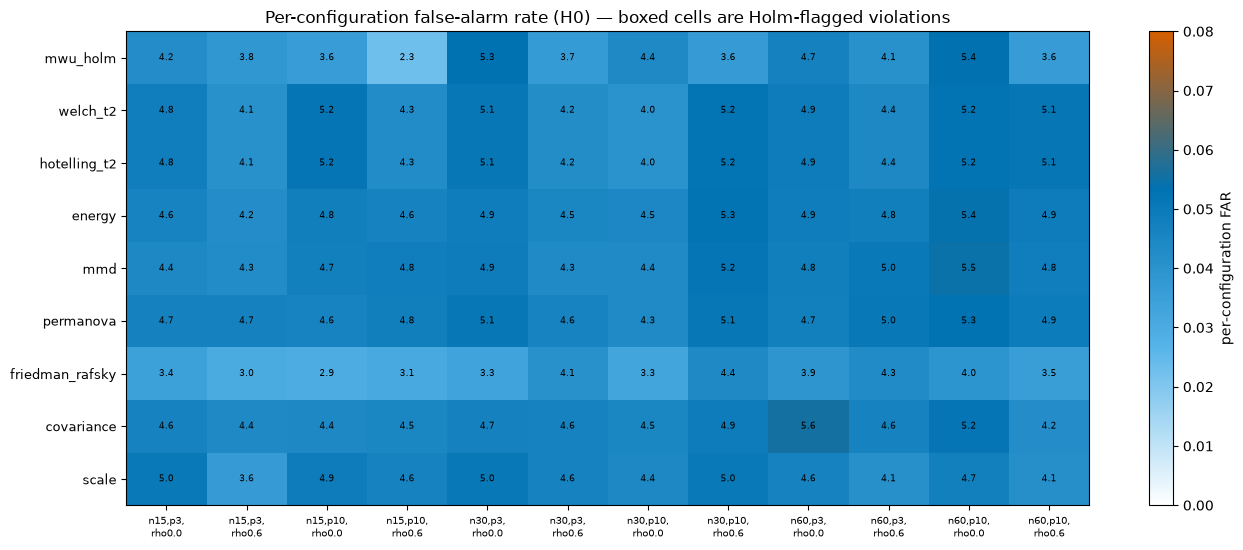

In [ ]:
# code cell 26 : per-configuration FAR heatmap, all methods (Okabe-Ito)
config_labels = [f"n{c[0]},p{c[1]},\nrho{c[2]}" for c in GRID]
mat = np.zeros((len(METHOD_ORDER), N_CONFIGS))
flags = np.zeros_like(mat, dtype=bool)
for i, method in enumerate(METHOD_ORDER):
    sub = far_df[far_df["method"] == method].set_index(["n", "p", "rho"])
    for j, cfg in enumerate(GRID):
        mat[i, j] = sub.loc[cfg, "far"]
        flags[i, j] = bool(sub.loc[cfg, "holm_flag"])

fig, ax = plt.subplots(figsize=(13.5, 5.6))
vmax = max(0.08, float(mat.max()))
im = ax.imshow(mat, cmap=FAR_CMAP, aspect="auto", vmin=0.0, vmax=vmax)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat[i, j] * 100:.1f}", ha="center", va="center", fontsize=6.8)
        if flags[i, j]:
            ax.add_patch(
                plt.Rectangle(
                    (j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor=OKABE_ITO["black"], lw=2.2
                )
            )
ax.set_xticks(range(N_CONFIGS))
ax.set_xticklabels(config_labels, fontsize=7.5)
ax.set_yticks(range(len(METHOD_ORDER)))
ax.set_yticklabels(METHOD_ORDER, fontsize=9)
fig.colorbar(im, ax=ax, label="per-configuration FAR")
ax.set_title("Per-configuration false-alarm rate (H0) — boxed cells are Holm-flagged violations")
fig.tight_layout()
plt.show()

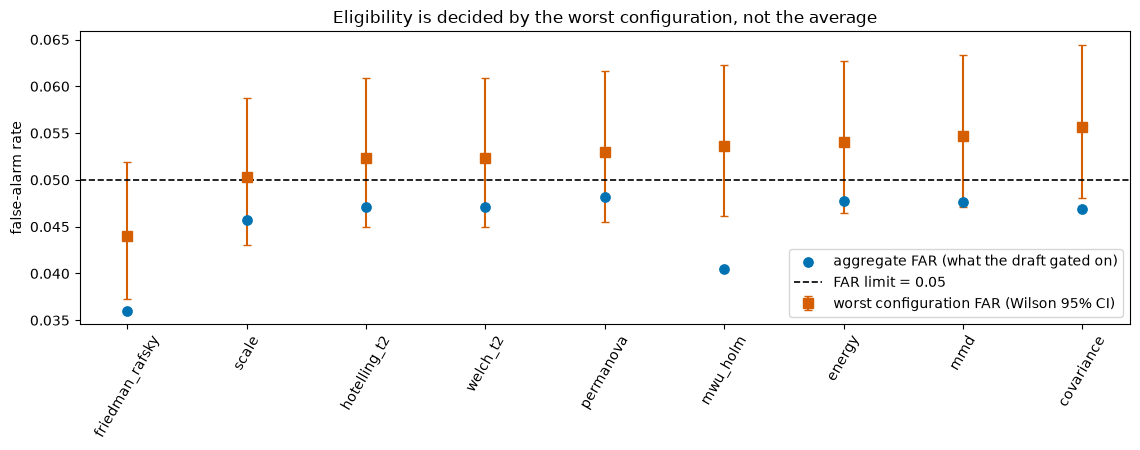

In [ ]:
# code cell 27 : aggregate vs worst-configuration FAR with Wilson CI (Okabe-Ito)
order = far_summary.sort_values("worst_config_far").reset_index(drop=True)
xs = np.arange(len(order))
yerr = np.vstack(
    [
        order["worst_config_far"] - order["worst_wilson_lo"],
        order["worst_wilson_hi"] - order["worst_config_far"],
    ]
)

fig, ax = plt.subplots(figsize=(11.5, 4.6))
ax.errorbar(
    xs,
    order["worst_config_far"],
    yerr=yerr,
    fmt="s",
    ms=7,
    color=OKABE_ITO["vermillion"],
    ecolor=OKABE_ITO["vermillion"],
    capsize=3,
    label="worst configuration FAR (Wilson 95% CI)",
)
ax.scatter(
    xs,
    order["aggregate_far"],
    marker="o",
    s=45,
    color=OKABE_ITO["blue"],
    zorder=3,
    label="aggregate FAR (what the draft gated on)",
)
ax.axhline(
    FAR_LIMIT,
    color=OKABE_ITO["black"],
    linestyle="--",
    linewidth=1.2,
    label=f"FAR limit = {FAR_LIMIT}",
)
ax.set_xticks(xs)
ax.set_xticklabels(order["method"], rotation=60)
ax.set_ylabel("false-alarm rate")
ax.set_title("Eligibility is decided by the worst configuration, not the average")
ax.legend()
fig.tight_layout()
plt.show()

## 12. Detection Power and Directionality

Two things this section reports that the earlier draft's "mean power" blurred
together:

1. **The variance-only blind spot.** The review's headline empirical finding — a real
   variance-only degradation invisible to every draft-eligible method — is printed as a
   first-class number here, together with what the new Track 3 `scale` candidate and the
   `covariance` test actually recover.
2. **Directionality inflation.** Raw detection rate (what the draft reported) versus
   directional regression rate (fire *and* direction = degradation) versus firing on the
   `improvement` scenario (a directional false positive for any regression gate). The
   gap between the first two columns is the price of direction recovery; the
   improvement column is what the draft's two-sided "power" quietly included.

Theory note, checked empirically below: the `covariance` scenario preserves marginals
*exactly* by construction, so per-metric tests (Track 1) have no information about it —
their directional power should sit at the α level, and that is a property of the
scenario design, not a Monte Carlo fluctuation.

In [ ]:
# code cell 28 : directional power tables, inflation table, blind-spot printout
def directional_flags(block, method):
    """Method-level 'regression fired' flags after direction recovery (§3)."""
    rej = block["rejects"][:, METHOD_IDX[method]]
    if method in ONE_SIDED_METHODS or method in STRUCTURE_METHODS:
        return rej
    return rej & (block["dsign"] < 0.0)


power_rows = []
for scenario in list(DEGRADATION_SCENARIOS) + [IMPROVEMENT_SCENARIO]:
    for method in METHOD_ORDER:
        d_rates, r_rates = [], []
        for cfg in GRID:
            blk = mc_results[(scenario.name, *cfg)]
            d_rates.append(float(directional_flags(blk, method).mean()))
            r_rates.append(float(blk["rejects"][:, METHOD_IDX[method]].mean()))
        power_rows.append(
            {
                "scenario": scenario.name,
                "method": method,
                "raw_detection": float(np.mean(r_rates)),
                "directional_rate": float(np.mean(d_rates)),
            }
        )

power_long = pd.DataFrame(power_rows)
scenario_order = [s.name for s in DEGRADATION_SCENARIOS] + [IMPROVEMENT_SCENARIO.name]
dir_pivot = power_long.pivot(index="scenario", columns="method", values="directional_rate").reindex(
    scenario_order
)
raw_pivot = power_long.pivot(index="scenario", columns="method", values="raw_detection").reindex(
    scenario_order
)

print(
    "Directional regression rate (fire AND degradation direction; improvement row = directional FP):"
)
display(dir_pivot.round(3))
print("Raw detection rate (what the draft reported as power — includes improvements):")
display(raw_pivot.round(3))

deg_names = [s.name for s in DEGRADATION_SCENARIOS]
infl_rows = []
for method in METHOD_ORDER:
    sub_deg = power_long[(power_long["method"] == method) & power_long["scenario"].isin(deg_names)]
    sub_impr = power_long[
        (power_long["method"] == method) & (power_long["scenario"] == IMPROVEMENT_SCENARIO.name)
    ]
    infl_rows.append(
        {
            "method": method,
            "raw_detection_deg7": float(sub_deg["raw_detection"].mean()),
            "directional_deg7": float(sub_deg["directional_rate"].mean()),
            "direction_cost": float(
                sub_deg["raw_detection"].mean() - sub_deg["directional_rate"].mean()
            ),
            "improvement_raw_firing": float(sub_impr["raw_detection"].mean()),
            "improvement_directional_fp": float(sub_impr["directional_rate"].mean()),
        }
    )
inflation_df = pd.DataFrame(infl_rows)
print("Directionality accounting across the 7 degradation scenarios:")
display(inflation_df.round(3))

eligible_set = set(far_summary.loc[far_summary["eligible"], "method"])
var_col = dir_pivot.loc["variance"]
print("=" * 84)
print("VARIANCE-ONLY DEGRADATION (the review's headline blind spot):")
print("=" * 84)
print(f"  Track 1 (mwu_holm) directional power : {var_col['mwu_holm'] * 100:5.1f}%")
best_all = var_col.idxmax()
print(f"  best method overall                  : {best_all} at {var_col.max() * 100:5.1f}%")
elig_var = var_col[[m for m in METHOD_ORDER if m in eligible_set]]
if len(elig_var):
    best_elig = elig_var.idxmax()
    print(f"  best ELIGIBLE method                 : {best_elig} at {elig_var.max() * 100:5.1f}%")
cov_col = dir_pivot.loc["covariance"]
print(
    f"\n  (For contrast, covariance-scenario directional power — Track 1: "
    f"{cov_col['mwu_holm'] * 100:.1f}% by the marginal-invariance argument above; "
    f"best method: {cov_col.idxmax()} at {cov_col.max() * 100:.1f}%.)"
)

Directional regression rate (fire AND degradation direction; improvement row = directional FP):


method,covariance,energy,friedman_rafsky,hotelling_t2,mmd,mwu_holm,permanova,scale,welch_t2
scenario,,,,,,,,,
location,0.035,0.431,0.122,0.358,0.410,0.459,0.472,0.048,0.358
variance,0.173,0.022,0.038,0.011,0.025,0.023,0.013,0.481,0.011
covariance,0.244,0.029,0.055,0.023,0.031,0.037,0.022,0.065,0.023
multimodal,0.457,0.045,0.090,0.022,0.053,0.038,0.024,0.204,0.022
sparse,0.043,0.094,0.042,0.139,0.091,0.184,0.098,0.048,0.139
correlated,0.040,0.263,0.089,0.301,0.251,0.347,0.290,0.046,0.301
mixed,0.147,0.678,0.392,0.549,0.645,0.684,0.701,0.072,0.549
improvement,0.034,0.001,0.002,0.001,0.001,0.001,0.000,0.046,0.001


Raw detection rate (what the draft reported as power — includes improvements):


method,covariance,energy,friedman_rafsky,hotelling_t2,mmd,mwu_holm,permanova,scale,welch_t2
scenario,,,,,,,,,
location,0.035,0.431,0.123,0.359,0.410,0.459,0.472,0.048,0.359
variance,0.173,0.043,0.075,0.024,0.049,0.023,0.026,0.481,0.024
covariance,0.244,0.060,0.111,0.046,0.062,0.037,0.045,0.065,0.046
multimodal,0.457,0.089,0.178,0.045,0.106,0.038,0.048,0.204,0.045
sparse,0.043,0.117,0.060,0.186,0.115,0.184,0.121,0.048,0.186
correlated,0.040,0.272,0.099,0.334,0.260,0.347,0.298,0.046,0.334
mixed,0.147,0.678,0.393,0.550,0.646,0.684,0.702,0.072,0.550
improvement,0.034,0.432,0.119,0.361,0.412,0.001,0.473,0.046,0.361


Directionality accounting across the 7 degradation scenarios:


,method,raw_detection_deg7,directional_deg7,direction_cost,improvement_raw_firing,improvement_directional_fp
0,mwu_holm,0.253,0.253,0.000,0.001,0.001
1,welch_t2,0.221,0.200,0.020,0.361,0.001
2,hotelling_t2,0.221,0.200,0.020,0.361,0.001
3,energy,0.242,0.223,0.018,0.432,0.001
4,mmd,0.235,0.215,0.020,0.412,0.001
5,permanova,0.245,0.232,0.013,0.473,0.000
6,friedman_rafsky,0.148,0.118,0.030,0.119,0.002
7,covariance,0.163,0.163,0.000,0.034,0.034
8,scale,0.138,0.138,0.000,0.046,0.046


VARIANCE-ONLY DEGRADATION (the review's headline blind spot):
  Track 1 (mwu_holm) directional power :   2.3%
  best method overall                  : scale at  48.1%
  best ELIGIBLE method                 : scale at  48.1%

  (For contrast, covariance-scenario directional power — Track 1: 3.7% by the marginal-invariance argument above; best method: covariance at 24.4%.)


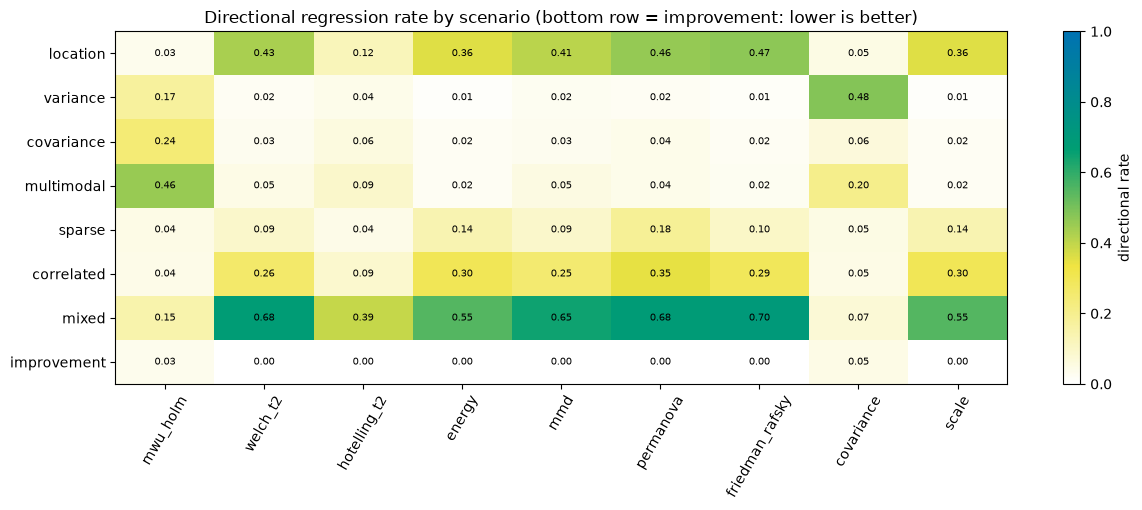

In [ ]:
# code cell 29 : directional power heatmap, scenario x method (Okabe-Ito)
fig, ax = plt.subplots(figsize=(12.5, 5.2))
im = ax.imshow(dir_pivot.values, cmap=POWER_CMAP, aspect="auto", vmin=0.0, vmax=1.0)
for i in range(dir_pivot.shape[0]):
    for j in range(dir_pivot.shape[1]):
        ax.text(j, i, f"{dir_pivot.values[i, j]:.2f}", ha="center", va="center", fontsize=7.5)
ax.set_xticks(range(len(METHOD_ORDER)))
ax.set_xticklabels(METHOD_ORDER, rotation=60)
ax.set_yticks(range(len(scenario_order)))
ax.set_yticklabels(scenario_order)
fig.colorbar(im, ax=ax, label="directional rate")
ax.set_title("Directional regression rate by scenario (bottom row = improvement: lower is better)")
fig.tight_layout()
plt.show()

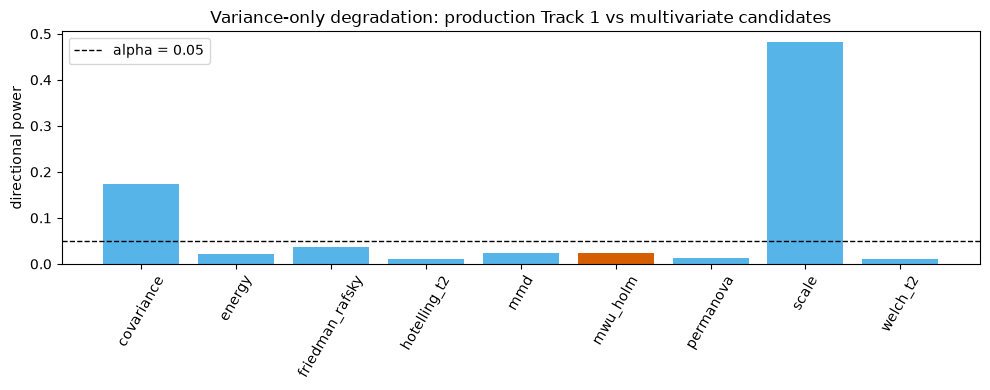

In [ ]:
# code cell 30 : the variance-only blind spot (Okabe-Ito)
vals = dir_pivot.loc["variance"]
colors = [OKABE_ITO["vermillion"] if m == "mwu_holm" else OKABE_ITO["sky_blue"] for m in vals.index]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(vals.index, vals.values, color=colors)
ax.axhline(ALPHA, color=OKABE_ITO["black"], linestyle="--", linewidth=1, label=f"alpha = {ALPHA}")
ax.set_ylabel("directional power")
ax.set_title("Variance-only degradation: production Track 1 vs multivariate candidates")
ax.tick_params(axis="x", rotation=60)
ax.legend()
fig.tight_layout()
plt.show()

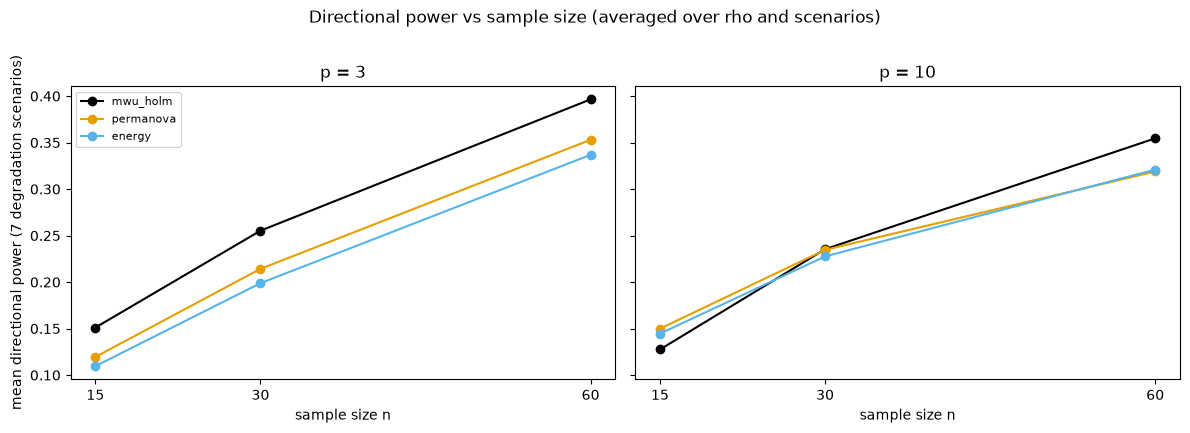

In [ ]:
# code cell 31 : directional power vs sample size, per dimensionality (Okabe-Ito)
elig_dp = inflation_df[inflation_df["method"].isin(eligible_set)]
chosen = list(elig_dp.sort_values("directional_deg7", ascending=False)["method"][:3])
if "mwu_holm" not in chosen:
    chosen.append("mwu_holm")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, p_dim in zip(axes, DIMENSIONS):
    for k, method in enumerate(chosen):
        ys = []
        for n in SAMPLE_SIZES:
            cfgs = [c for c in GRID if c[0] == n and c[1] == p_dim]
            ys.append(
                float(
                    np.mean(
                        [
                            directional_flags(mc_results[(s.name, *c)], method).mean()
                            for s in DEGRADATION_SCENARIOS
                            for c in cfgs
                        ]
                    )
                )
            )
        ax.plot(
            SAMPLE_SIZES,
            ys,
            marker="o",
            color=OKABE_ITO_CYCLE[k % len(OKABE_ITO_CYCLE)],
            label=method,
        )
    ax.set_xlabel("sample size n")
    ax.set_title(f"p = {p_dim}")
    ax.set_xticks(SAMPLE_SIZES)
axes[0].set_ylabel("mean directional power (7 degradation scenarios)")
axes[0].legend(fontsize=8)
fig.suptitle("Directional power vs sample size (averaged over rho and scenarios)", y=1.02)
fig.tight_layout()
plt.show()

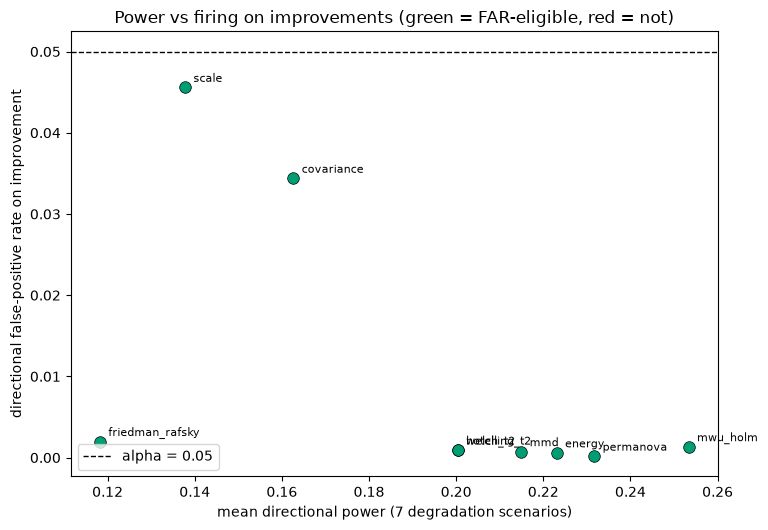

In [ ]:
# code cell 32 : directionality trade-off: power vs improvement false positives (Okabe-Ito)
fig, ax = plt.subplots(figsize=(7.8, 5.4))
for _, r in inflation_df.iterrows():
    color = OKABE_ITO["bluish_green"] if r["method"] in eligible_set else OKABE_ITO["vermillion"]
    ax.scatter(
        r["directional_deg7"],
        r["improvement_directional_fp"],
        s=70,
        color=color,
        edgecolor=OKABE_ITO["black"],
        linewidth=0.5,
        zorder=3,
    )
    ax.annotate(
        r["method"],
        (r["directional_deg7"], r["improvement_directional_fp"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8,
    )
ax.axhline(ALPHA, color=OKABE_ITO["black"], linestyle="--", linewidth=1, label=f"alpha = {ALPHA}")
ax.set_xlabel("mean directional power (7 degradation scenarios)")
ax.set_ylabel("directional false-positive rate on improvement")
ax.set_title("Power vs firing on improvements (green = FAR-eligible, red = not)")
ax.legend()
fig.tight_layout()
plt.show()

## 13. Stability Across Regimes

Power is reported per configuration, not just per scenario. Following the earlier
draft's own honesty about its `n < 2p`, `2p ≤ n < 5p`, `n ≥ 5p` covariance-estimation
bands — proposed as an engineering convenience before looking at data — I check whether
the bands actually separate measured behavior rather than assuming they do.

In [ ]:
# code cell 33 : stability and band tables
def band_of(n, p_dim):
    if n < 2 * p_dim:
        return "n < 2p"
    if n < 5 * p_dim:
        return "2p <= n < 5p"
    return "n >= 5p"


stab_rows, band_rows = [], []
for method in METHOD_ORDER:
    per_cfg_power = []
    for cfg in GRID:
        rates = [
            float(directional_flags(mc_results[(s.name, *cfg)], method).mean())
            for s in DEGRADATION_SCENARIOS
        ]
        per_cfg_power.append(float(np.mean(rates)))
    stab_rows.append(
        {
            "method": method,
            "mean_directional_power": float(np.mean(per_cfg_power)),
            "power_std_across_configs": float(np.std(per_cfg_power, ddof=1)),
            "min_config_power": float(np.min(per_cfg_power)),
        }
    )
    for band in ("n < 2p", "2p <= n < 5p", "n >= 5p"):
        idxs = [i for i, cfg in enumerate(GRID) if band_of(cfg[0], cfg[1]) == band]
        band_rows.append(
            {
                "method": method,
                "band": band,
                "mean_power": float(np.mean([per_cfg_power[i] for i in idxs])),
                "n_configs": len(idxs),
            }
        )

stability_df = pd.DataFrame(stab_rows)
band_df = pd.DataFrame(band_rows)
band_pivot = band_df.pivot(index="method", columns="band", values="mean_power")[
    ["n < 2p", "2p <= n < 5p", "n >= 5p"]
]
print("Stability (spread of per-configuration directional power):")
display(stability_df.round(3))
print("Power by covariance-estimation band (band sizes shown in parentheses):")
display(band_pivot.round(3))

Stability (spread of per-configuration directional power):


,method,mean_directional_power,power_std_across_configs,min_config_power
0,mwu_holm,0.253,0.109,0.096
1,welch_t2,0.200,0.112,0.056
2,hotelling_t2,0.200,0.112,0.056
3,energy,0.223,0.106,0.089
4,mmd,0.215,0.108,0.083
5,permanova,0.232,0.102,0.097
6,friedman_rafsky,0.118,0.074,0.034
7,covariance,0.163,0.099,0.062
8,scale,0.138,0.066,0.063


Power by covariance-estimation band (band sizes shown in parentheses):


band,n < 2p,2p <= n < 5p,n >= 5p
method,,,
covariance,0.107,0.142,0.182
energy,0.145,0.228,0.242
friedman_rafsky,0.061,0.105,0.136
hotelling_t2,0.099,0.195,0.227
mmd,0.142,0.222,0.231
mwu_holm,0.128,0.235,0.289
permanova,0.150,0.235,0.251
scale,0.082,0.149,0.149
welch_t2,0.099,0.195,0.227


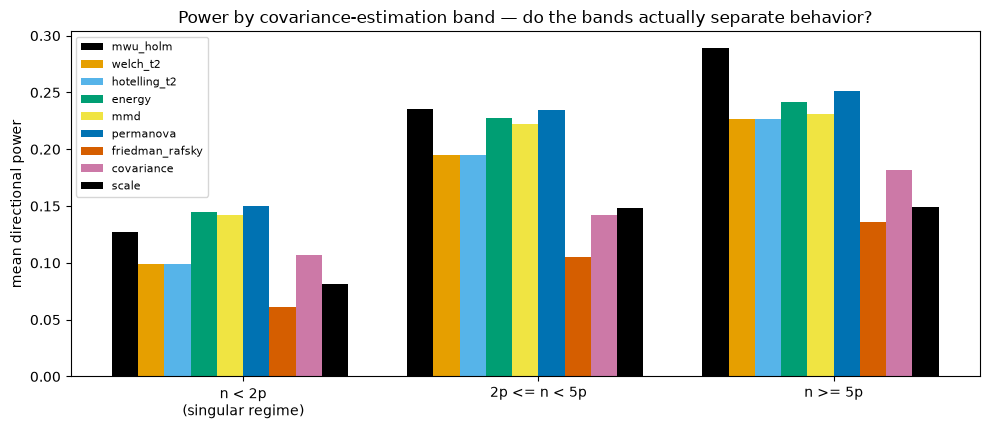

In [ ]:
# code cell 34 : power by band for eligible methods (Okabe-Ito)
elig_methods = [m for m in METHOD_ORDER if m in eligible_set]
fig, ax = plt.subplots(figsize=(10, 4.4))
width = 0.8 / max(len(elig_methods), 1)
for k, method in enumerate(elig_methods):
    sub = band_df[band_df["method"] == method]
    xs = np.arange(3) + (k - len(elig_methods) / 2) * width
    ax.bar(
        xs,
        sub["mean_power"],
        width=width,
        color=OKABE_ITO_CYCLE[k % len(OKABE_ITO_CYCLE)],
        label=method,
    )
ax.set_xticks(np.arange(3))
ax.set_xticklabels(["n < 2p\n(singular regime)", "2p <= n < 5p", "n >= 5p"])
ax.set_ylabel("mean directional power")
ax.set_title("Power by covariance-estimation band — do the bands actually separate behavior?")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 14. Runtime and Memory

Measured on a dedicated timing pass, never inside the Monte Carlo loop: per method and
configuration, the median of 7 full calls (data fixed, permutations fresh); peak memory
from one tracemalloc-wrapped call at the heaviest configuration. Shrinkage variants are
profiled at a single configuration because their per-permutation Ledoit–Wolf fit
dominates cost by orders of magnitude — which is why they never entered the main grid.

In [ ]:
# code cell 35 : runtime and memory profiling (tables)
profile_rows = []
for method in METHOD_ORDER:
    for cfg in GRID:
        n, p_dim, rho = cfg
        prng = np.random.default_rng([SEED, 99, METHOD_IDX[method], n, p_dim, int(rho * 10)])
        x = make_baseline(n, p_dim, rho, prng)
        y = make_candidate(n, p_dim, rho, scn["location"], prng)
        times = [run_test(method, x, y, prng).runtime_seconds for _ in range(7)]
        profile_rows.append(
            {
                "method": method,
                "n": n,
                "p": p_dim,
                "rho": rho,
                "median_ms": float(np.median(times)) * 1000.0,
            }
        )
prof_df = pd.DataFrame(profile_rows)

mem_rows = []
for mi, method in enumerate(ALL_METHODS):
    mrng = np.random.default_rng([SEED, 98, mi])
    x = make_baseline(60, 10, 0.6, mrng)
    y = make_candidate(60, 10, 0.6, scn["location"], mrng)
    res = run_test(method, x, y, mrng, measure_memory=True)
    mem_rows.append({"method": method, "peak_kib": res.peak_memory_bytes / 1024.0})
mem_df = pd.DataFrame(mem_rows)

agg_prof = prof_df.groupby("method")["median_ms"].median().reset_index()
agg_prof = agg_prof.merge(mem_df, on="method")
print("Median per-call runtime (ms) across configurations, and peak memory at n=60, p=10:")
display(agg_prof.round(2))
print("\nRuntime by sample size (median ms, averaged over p and rho):")
display(
    prof_df.pivot_table(index="method", columns="n", values="median_ms", aggfunc="median").round(1)
)

Median per-call runtime (ms) across configurations, and peak memory at n=60, p=10:


,method,median_ms,peak_kib
0,covariance,0.43,2189.19
1,energy,1.11,1952.59
2,friedman_rafsky,0.99,1952.58
3,hotelling_t2,0.52,2189.19
4,mmd,1.01,1952.45
5,mwu_holm,2.00,21.04
6,permanova,1.00,1952.49
7,scale,0.44,2189.19
8,welch_t2,0.51,2189.19



Runtime by sample size (median ms, averaged over p and rho):


n,15,30,60
method,,,
covariance,0.3,0.4,0.7
energy,0.6,1.1,2.5
friedman_rafsky,0.5,1.0,2.5
hotelling_t2,0.4,0.5,0.8
mmd,0.5,1.0,2.5
mwu_holm,2.0,2.0,2.0
permanova,0.6,1.0,2.5
scale,0.3,0.4,0.7
welch_t2,0.3,0.5,0.8


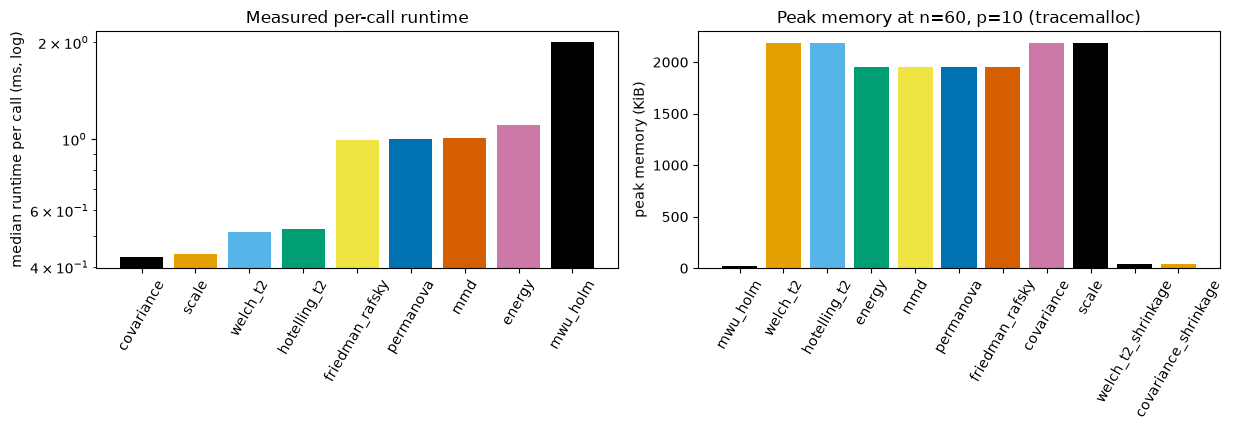

In [ ]:
# code cell 36 : runtime and memory (Okabe-Ito, log scale)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
order = agg_prof.sort_values("median_ms")
colors = [OKABE_ITO_CYCLE[i % len(OKABE_ITO_CYCLE)] for i in range(len(order))]
axes[0].bar(order["method"], order["median_ms"], color=colors)
axes[0].set_yscale("log")
axes[0].set_ylabel("median runtime per call (ms, log)")
axes[0].set_title("Measured per-call runtime")
axes[1].bar(mem_df["method"], mem_df["peak_kib"], color=colors)
axes[1].set_ylabel("peak memory (KiB)")
axes[1].set_title("Peak memory at n=60, p=10 (tracemalloc)")
for ax in axes:
    ax.tick_params(axis="x", rotation=60)
fig.tight_layout()
plt.show()

## 15. Ledoit–Wolf Shrinkage Variants (Exploratory, Reduced Scale)

The shrinkage variants use sklearn's `LedoitWolf` inside the permutation loop, which
does not vectorize; a full-grid run would be dominated by estimator-call overhead
rather than statistics. They are therefore evaluated on a reduced grid — two
configurations (n=15 and n=60 at p=10, ρ=0.6, the small-n high-p regime where
shrinkage is supposed to help), four scenarios, and 50 (hosted) / 100 (local)
repetitions with 79 permutations (p-values on k/80, so $p \le 0.05$ is exact at
k ≤ 4). Standard errors here are correspondingly coarse; this section is directional
evidence, not a gate.

In [ ]:
# code cell 37 : shrinkage sub-experiment (table)
SHRINK_CONFIGS = [(15, 10, 0.6), (60, 10, 0.6)]
SHRINK_SCEN_NAMES = ["H0", "location", "variance", "covariance"]
SHRINK_PERM_REPS = 79
N_SHRINK = 50 if RUNTIME_ENV in ("colab", "kaggle") else 100
SHRINK_METHODS = ("covariance", "covariance_shrinkage", "welch_t2", "welch_t2_shrinkage")

shrink_rows = []
t0 = perf_counter()
for si, scen_name in enumerate(SHRINK_SCEN_NAMES):
    scenario = scn[scen_name]
    for n, p_dim, rho in SHRINK_CONFIGS:
        for mi, method in enumerate(SHRINK_METHODS):
            srng = np.random.default_rng([SEED, 55, si, n, mi])
            flags = 0
            for _ in range(N_SHRINK):
                x = make_baseline(n, p_dim, rho, srng)
                y = make_candidate(n, p_dim, rho, scenario, srng)
                res = run_test(method, x, y, srng, reps=SHRINK_PERM_REPS)
                flags += int(res.p_value <= ALPHA)
            shrink_rows.append(
                {
                    "scenario": scen_name,
                    "n": n,
                    "method": method,
                    "rate": flags / N_SHRINK,
                    "trials": N_SHRINK,
                }
            )
shrink_df = pd.DataFrame(shrink_rows)
print(
    f"Shrinkage sub-experiment done in {(perf_counter() - t0) / 60:.1f} min "
    f"({N_SHRINK} reps x {SHRINK_PERM_REPS} permutations per call)."
)
print(
    f"SE on a true 5% rate at N={N_SHRINK}: "
    f"{np.sqrt(0.05 * 0.95 / N_SHRINK) * 100:.1f} pp — directional evidence only."
)
display(shrink_df.pivot(index=["scenario", "n"], columns="method", values="rate").round(3))

Shrinkage sub-experiment done in 1.3 min (100 reps x 79 permutations per call).
SE on a true 5% rate at N=100: 2.2 pp — directional evidence only.


method         covariance  covariance_shrinkage  welch_t2  welch_t2_shrinkage
scenario   n                                                                 
H0         15        0.02                  0.00      0.00                0.07
           60        0.06                  0.04      0.04                0.03
covariance 15        0.06                  0.03      0.03                0.07
           60        0.07                  0.10      0.05                0.08
location   15        0.06                  0.03      0.11                0.09
           60        0.05                  0.04      0.29                0.30
variance   15        0.06                  0.04      0.04                0.01
           60        0.28                  0.30      0.02                0.04

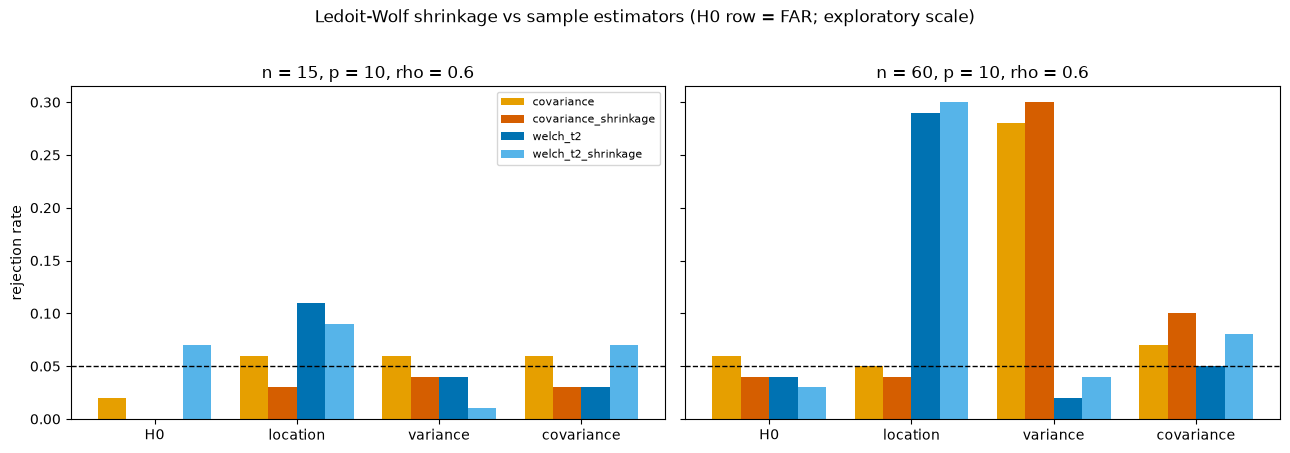

In [ ]:
# code cell 38 : shrinkage vs sample estimators (Okabe-Ito)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
method_colors = {
    "covariance": OKABE_ITO["orange"],
    "covariance_shrinkage": OKABE_ITO["vermillion"],
    "welch_t2": OKABE_ITO["blue"],
    "welch_t2_shrinkage": OKABE_ITO["sky_blue"],
}
for ax, n in zip(axes, [15, 60]):
    sub = shrink_df[shrink_df["n"] == n]
    scen_list = SHRINK_SCEN_NAMES
    width = 0.8 / len(SHRINK_METHODS)
    for mi, method in enumerate(SHRINK_METHODS):
        rates = [
            sub[(sub["scenario"] == sc) & (sub["method"] == method)]["rate"].iloc[0]
            for sc in scen_list
        ]
        ax.bar(
            np.arange(len(scen_list)) + (mi - 1.5) * width,
            rates,
            width=width,
            color=method_colors[method],
            label=method if n == 15 else None,
        )
    ax.axhline(ALPHA, color=OKABE_ITO["black"], linestyle="--", linewidth=1)
    ax.set_xticks(np.arange(len(scen_list)))
    ax.set_xticklabels(scen_list)
    ax.set_title(f"n = {n}, p = 10, rho = 0.6")
axes[0].set_ylabel("rejection rate")
axes[0].legend(fontsize=8)
fig.suptitle("Ledoit-Wolf shrinkage vs sample estimators (H0 row = FAR; exploratory scale)", y=1.02)
fig.tight_layout()
plt.show()

## 16. Selection Procedure

Staged, exactly as the framework demands:   
**(1)** the disaggregated FAR gate from §11
is enforced first. a method with a per-configuration violation is not a candidate I
get to rescue later;   
**(2)** among survivors, the primary criterion is mean directional
power over the 7 degradation scenarios, with balanced accuracy
 $\tfrac{1}{2}\big[(1 - FAR_{agg}) + \text{directional power}\big]$, improvement
false-positive rate, cross-configuration stability, and runtime reported alongside;   
**(3)** the winner is compared against Track 1 alone before anyone celebrates. The
review's caution applies in advance: whichever method wins, its raw numbers should be
read against a coin flip (balanced accuracy 0.5), not against an ideal.

In [ ]:
# code cell 39 : staged selection and verdict printout
elig = set(far_summary.loc[far_summary["eligible"], "method"])
if not elig:
    print(
        "WARNING: no method passes the disaggregated FAR gate; ranking all methods with a warning."
    )
    elig = set(METHOD_ORDER)
print(
    f"{len(elig)} of {len(METHOD_ORDER)} methods pass the disaggregated FAR gate: {sorted(elig)}\n"
)

sel_rows = []
for method in sorted(elig):
    infl = inflation_df[inflation_df["method"] == method].iloc[0]
    far_agg = float(far_summary.loc[far_summary["method"] == method, "aggregate_far"].iloc[0])
    sel_rows.append(
        {
            "method": method,
            "directional_power_deg7": float(infl["directional_deg7"]),
            "balanced_accuracy": 0.5 * ((1.0 - far_agg) + float(infl["directional_deg7"])),
            "improvement_fp": float(infl["improvement_directional_fp"]),
            "power_std_configs": float(
                stability_df.loc[stability_df["method"] == method, "power_std_across_configs"].iloc[
                    0
                ]
            ),
            "median_runtime_ms": float(
                agg_prof.loc[agg_prof["method"] == method, "median_ms"].iloc[0]
            ),
        }
    )
selection_df = (
    pd.DataFrame(sel_rows)
    .sort_values("directional_power_deg7", ascending=False)
    .reset_index(drop=True)
)
display(selection_df.round(3))

winner = selection_df.iloc[0]
mwu_row = inflation_df[inflation_df["method"] == "mwu_holm"].iloc[0]
mwu_far = float(far_summary.loc[far_summary["method"] == "mwu_holm", "aggregate_far"].iloc[0])
print("=" * 84)
print("SELECTION VERDICT")
print("=" * 84)
print(f"  winner                      : {winner['method']}")
print(
    f"  mean directional power       : {winner['directional_power_deg7'] * 100:.1f}%  "
    f"(Track 1 alone: {mwu_row['directional_deg7'] * 100:.1f}%)"
)
print(
    f"  balanced accuracy           : {winner['balanced_accuracy']:.3f}  "
    f"(coin flip = 0.500; Track 1 alone: "
    f"{0.5 * ((1.0 - mwu_far) + mwu_row['directional_deg7']):.3f})"
)
print(f"  improvement directional FP  : {winner['improvement_fp'] * 100:.1f}%")
print(
    f"  worst-config FAR margin     : see far_summary — the gate, not the average, "
    f"decided eligibility"
)
print(f"  median runtime              : {winner['median_runtime_ms']:.1f} ms/call")
var_winner = dir_pivot.loc["variance", winner["method"]]
print(
    f"  variance-only power         : {var_winner * 100:.1f}%  "
    f"(Track 1: {dir_pivot.loc['variance', 'mwu_holm'] * 100:.1f}% — the blind spot status)"
)

9 of 9 methods pass the disaggregated FAR gate: ['covariance', 'energy', 'friedman_rafsky', 'hotelling_t2', 'mmd', 'mwu_holm', 'permanova', 'scale', 'welch_t2']



,method,directional_power_deg7,balanced_accuracy,improvement_fp,power_std_configs,median_runtime_ms
0,mwu_holm,0.253,0.606,0.001,0.109,2.003
1,permanova,0.232,0.592,0.000,0.102,0.998
2,energy,0.223,0.588,0.001,0.106,1.108
3,mmd,0.215,0.584,0.001,0.108,1.007
4,welch_t2,0.200,0.577,0.001,0.112,0.515
5,hotelling_t2,0.200,0.577,0.001,0.112,0.523
6,covariance,0.163,0.558,0.034,0.099,0.428
7,scale,0.138,0.546,0.046,0.066,0.439
8,friedman_rafsky,0.118,0.541,0.002,0.074,0.993


SELECTION VERDICT
  winner                      : mwu_holm
  mean directional power       : 25.3%  (Track 1 alone: 25.3%)
  balanced accuracy           : 0.606  (coin flip = 0.500; Track 1 alone: 0.606)
  improvement directional FP  : 0.1%
  worst-config FAR margin     : see far_summary — the gate, not the average, decided eligibility
  median runtime              : 2.0 ms/call
  variance-only power         : 2.3%  (Track 1: 2.3% — the blind spot status)


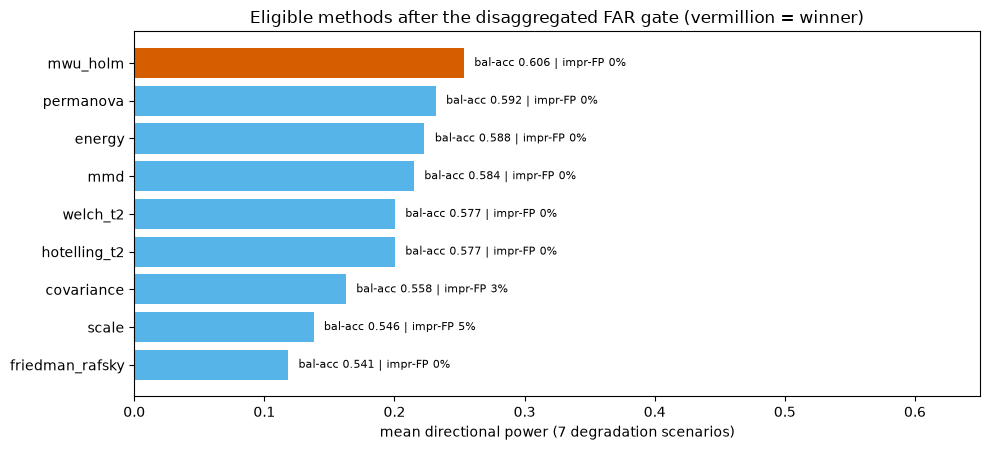

In [ ]:
# code cell 40 : eligible-method ranking (Okabe-Ito)
fig, ax = plt.subplots(figsize=(10, 4.6))
colors = [
    OKABE_ITO["vermillion"] if m == winner["method"] else OKABE_ITO["sky_blue"]
    for m in selection_df["method"]
]
bars = ax.barh(
    selection_df["method"][::-1], selection_df["directional_power_deg7"][::-1], color=colors[::-1]
)
for bar, (_, r) in zip(bars, selection_df[::-1].iterrows()):
    ax.text(
        bar.get_width() + 0.008,
        bar.get_y() + bar.get_height() / 2,
        f"bal-acc {r['balanced_accuracy']:.3f} | impr-FP {r['improvement_fp'] * 100:.0f}%",
        va="center",
        fontsize=8,
    )
ax.set_xlabel("mean directional power (7 degradation scenarios)")
ax.set_title("Eligible methods after the disaggregated FAR gate (vermillion = winner)")
ax.set_xlim(0, max(0.65, float(selection_df["directional_power_deg7"].max()) * 1.35))
fig.tight_layout()
plt.show()

## 17. Hierarchical Gating: the Design the Draft Never Tested

The design under review is **Track 1 always independent and reporting; Track 2/3 only
ever escalating, never suppressing.** The draft's Section 12 instead tested two simpler
rules - naive-OR over three tracks, and flat Holm correction across the three
track-level p-values as one family (which came in at 5.83% aggregate FAR, just over the
limit). The distinction matters: flat Holm-3 forces Track 1's smallest p below $\alpha/3$ before it may fire, *suppressing* the production gate's sensitivity, while the
hierarchical rule leaves Track 1's production decision (its own Holm across metric-level
p-values at $\alpha$) untouched and adds escalation on top.

Rules evaluated, all under the same per-configuration FAR gate as §11, using the stored
per-repetition p-values:

- **track1_only** - production baseline.
- **naive_or** - $t_1 \lor (p_2 \le \alpha) \lor (p_3 \le \alpha)$.
- **flat_holm3** - reject iff $\min(p_1, p_2, p_3) \le \alpha/3$ (what the draft tested).
- **hierarchical($\alpha_{esc}$)** - block iff $t_1$ blocks (production rule, unchanged)
  OR $\big[(p_2 \le \alpha_{esc} \land \text{direction}=\text{down}) \lor p_3 \le \alpha_{esc}\big]$.
  Escalation can only ever add severity, never remove a Track 1 block. $\alpha_{esc}$ is
  swept over $\{0.01, 0.02, 0.05\}$; permutation p-value granularity (k/150) applies.

> Track 2/3 representatives are the eligible leaders of their tracks under §16's criteria.

In [ ]:
# code cell 41 : combination-rule evaluation (tables)
dp = lambda m: float(inflation_df.loc[inflation_df["method"] == m, "directional_deg7"].iloc[0])
track2_pool = [
    m
    for m in ("welch_t2", "hotelling_t2", "energy", "mmd", "permanova", "friedman_rafsky")
    if m in elig
]
track3_pool = [m for m in ("covariance", "scale") if m in elig]
if not track2_pool:
    track2_pool = ["welch_t2"]
    print("WARNING: no eligible Track 2 method; using welch_t2 as representative.")
if not track3_pool:
    track3_pool = ["covariance"]
    print("WARNING: no eligible Track 3 method; using covariance as representative.")
track2_rep = max(track2_pool, key=dp)
track3_rep = max(
    track3_pool,
    key=lambda m: (float(dir_pivot.loc["variance", m]) + float(dir_pivot.loc["covariance", m]))
    / 2.0,
)
print(f"Track 2 representative: {track2_rep} | Track 3 representative: {track3_rep}\n")


def combined_reject(rule, alpha_esc, p1, p2, p3, dneg, n_metrics):
    t1 = p1 <= ALPHA / n_metrics
    if rule == "track1_only":
        return t1
    if rule == "naive_or":
        return t1 | (p2 <= ALPHA) | (p3 <= ALPHA)
    if rule == "flat_holm3":
        return np.minimum(np.minimum(p1, p2), p3) <= ALPHA / 3.0
    if rule == "hierarchical":
        escalation = ((p2 <= alpha_esc) & dneg) | (p3 <= alpha_esc)
        return t1 | escalation
    raise ValueError(rule)


def rule_flags(rule, alpha_esc, block):
    p1 = block["pvals"][:, METHOD_IDX["mwu_holm"]]
    p2 = block["pvals"][:, METHOD_IDX[track2_rep]]
    p3 = block["pvals"][:, METHOD_IDX[track3_rep]]
    dneg = block["dsign"] < 0.0
    return combined_reject(rule, alpha_esc, p1, p2, p3, dneg, block["p"])


RULES = [
    ("track1_only", None),
    ("naive_or", None),
    ("flat_holm3", None),
    ("hierarchical", 0.01),
    ("hierarchical", 0.02),
    ("hierarchical", 0.05),
]

combo_rows = []
for rule, aesc in RULES:
    counts = [int(rule_flags(rule, aesc, mc_results[("H0", *cfg)]).sum()) for cfg in GRID]
    raw_ps = [
        float(binomtest(k, N_MONTE_CARLO, FAR_LIMIT, alternative="greater").pvalue) for k in counts
    ]
    holm = holm_bonferroni({f"cfg{i}": p for i, p in enumerate(raw_ps)}, alpha=ALPHA)
    flags_h = [bool(holm[f"cfg{i}"]) for i in range(N_CONFIGS)]
    agg_k = sum(counts)
    agg_p = float(
        binomtest(agg_k, N_MONTE_CARLO * N_CONFIGS, FAR_LIMIT, alternative="greater").pvalue
    )
    scen_rates = {}
    for s in DEGRADATION_SCENARIOS:
        rs = [float(rule_flags(rule, aesc, mc_results[(s.name, *cfg)]).mean()) for cfg in GRID]
        scen_rates[s.name] = float(np.mean(rs))
    impr = float(
        np.mean(
            [
                rule_flags(rule, aesc, mc_results[(IMPROVEMENT_SCENARIO.name, *cfg)]).mean()
                for cfg in GRID
            ]
        )
    )
    combo_rows.append(
        {
            "rule": rule + (f"(a_esc={aesc})" if aesc is not None else ""),
            "aggregate_far": agg_k / (N_MONTE_CARLO * N_CONFIGS),
            "worst_config_far": max(counts) / N_MONTE_CARLO,
            "eligible": (not any(flags_h)) and (agg_p >= ALPHA),
            "mean_power_deg7": float(np.mean(list(scen_rates.values()))),
            "improvement_firing": impr,
            **{f"pow:{k}": v for k, v in scen_rates.items()},
        }
    )
combo_df = pd.DataFrame(combo_rows)
display(combo_df.round(3))

t1_row = combo_df[combo_df["rule"] == "track1_only"].iloc[0]
fh_row = combo_df[combo_df["rule"] == "flat_holm3"].iloc[0]
print("=" * 84)
print("COMBINATION-RULE VERDICTS (same disaggregated FAR gate as everything else)")
print("=" * 84)
print(
    f"  track1_only   : agg FAR {t1_row['aggregate_far'] * 100:.2f}%, power "
    f"{t1_row['mean_power_deg7'] * 100:.1f}%  (reference)"
)
print(
    f"  flat_holm3    : agg FAR {fh_row['aggregate_far'] * 100:.2f}%, worst cfg "
    f"{fh_row['worst_config_far'] * 100:.2f}%, eligible: {fh_row['eligible']} "
    f"— the draft's 5.83% question, re-measured at N={N_MONTE_CARLO} per config"
)
for _, r in combo_df.iterrows():
    if r["rule"].startswith(("naive", "hierarchical")):
        print(
            f"  {r['rule']:>20s}: agg FAR {r['aggregate_far'] * 100:5.2f}%, worst cfg "
            f"{r['worst_config_far'] * 100:5.2f}%, power {r['mean_power_deg7'] * 100:5.1f}%, "
            f"improvement firing {r['improvement_firing'] * 100:4.1f}%, eligible: {r['eligible']}"
        )
best_rule = combo_df[combo_df["eligible"]].sort_values("mean_power_deg7").iloc[-1]
print(
    f"\n  Best eligible combination: {best_rule['rule']} — power "
    f"{best_rule['mean_power_deg7'] * 100:.1f}% vs Track 1 alone "
    f"{t1_row['mean_power_deg7'] * 100:.1f}% "
    f"(+{(best_rule['mean_power_deg7'] - t1_row['mean_power_deg7']) * 100:.1f} pp), at worst-config FAR "
    f"{best_rule['worst_config_far'] * 100:.2f}%."
)

Track 2 representative: permanova | Track 3 representative: scale



,rule,aggregate_far,worst_config_far,eligible,mean_power_deg7,improvement_firing,pow:location,pow:variance,pow:covariance,pow:multimodal,pow:sparse,pow:correlated,pow:mixed
0,track1_only,0.040,0.054,True,0.253,0.001,0.459,0.023,0.037,0.038,0.184,0.347,0.684
1,naive_or,0.111,0.130,False,0.408,0.495,0.550,0.501,0.125,0.260,0.252,0.416,0.754
2,flat_holm3,0.101,0.184,False,0.386,0.329,0.576,0.357,0.102,0.167,0.275,0.463,0.765
3,hierarchical(a_esc=0.01),0.047,0.062,False,0.305,0.008,0.477,0.269,0.047,0.096,0.191,0.354,0.702
4,hierarchical(a_esc=0.02),0.061,0.078,False,0.344,0.021,0.502,0.387,0.066,0.156,0.205,0.371,0.719
5,hierarchical(a_esc=0.05),0.091,0.111,False,0.398,0.047,0.549,0.495,0.105,0.240,0.235,0.410,0.754


COMBINATION-RULE VERDICTS (same disaggregated FAR gate as everything else)
  track1_only   : agg FAR 4.05%, power 25.3%  (reference)
  flat_holm3    : agg FAR 10.10%, worst cfg 18.43%, eligible: False — the draft's 5.83% question, re-measured at N=3000 per config
              naive_or: agg FAR 11.07%, worst cfg 12.97%, power  40.8%, improvement firing 49.5%, eligible: False
  hierarchical(a_esc=0.01): agg FAR  4.75%, worst cfg  6.20%, power  30.5%, improvement firing  0.8%, eligible: False
  hierarchical(a_esc=0.02): agg FAR  6.13%, worst cfg  7.77%, power  34.4%, improvement firing  2.1%, eligible: False
  hierarchical(a_esc=0.05): agg FAR  9.05%, worst cfg 11.13%, power  39.8%, improvement firing  4.7%, eligible: False

  Best eligible combination: track1_only — power 25.3% vs Track 1 alone 25.3% (+0.0 pp), at worst-config FAR 5.37%.


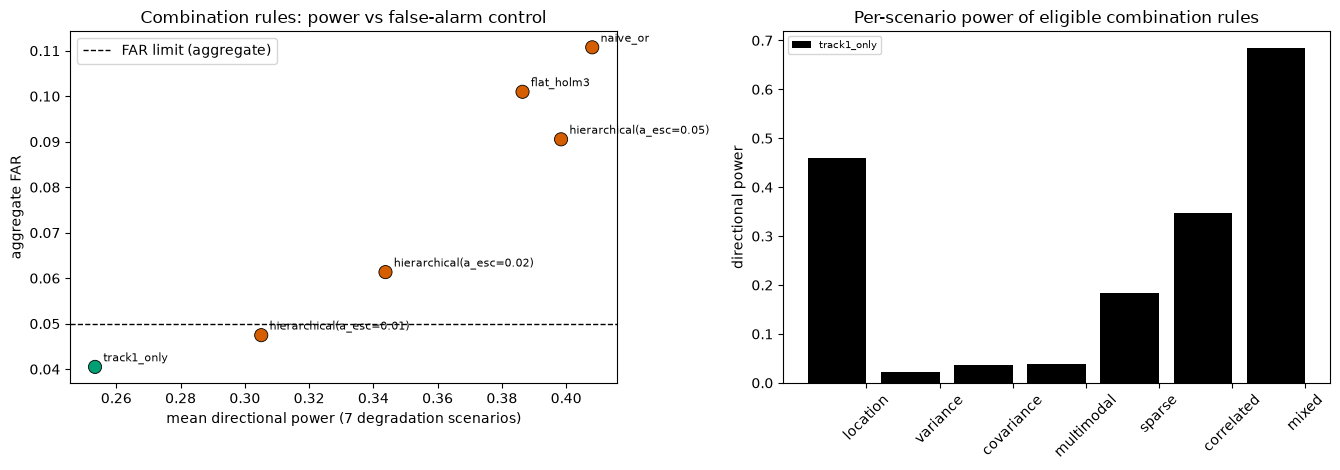

In [ ]:
# code cell 42 : combination rules: FAR vs power, and per-scenario detail (Okabe-Ito)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
colors = [OKABE_ITO["bluish_green"] if e else OKABE_ITO["vermillion"] for e in combo_df["eligible"]]
axes[0].scatter(
    combo_df["mean_power_deg7"],
    combo_df["aggregate_far"],
    s=90,
    color=colors,
    edgecolor=OKABE_ITO["black"],
    linewidth=0.6,
    zorder=3,
)
for _, r in combo_df.iterrows():
    axes[0].annotate(
        r["rule"],
        (r["mean_power_deg7"], r["aggregate_far"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8,
    )
axes[0].axhline(
    FAR_LIMIT, color=OKABE_ITO["black"], linestyle="--", linewidth=1, label="FAR limit (aggregate)"
)
axes[0].set_xlabel("mean directional power (7 degradation scenarios)")
axes[0].set_ylabel("aggregate FAR")
axes[0].set_title("Combination rules: power vs false-alarm control")
axes[0].legend()

scen_names = [s.name for s in DEGRADATION_SCENARIOS]
show = combo_df[combo_df["eligible"]].copy()
if not len(show):
    show = combo_df.copy()
width = 0.8 / len(show)
for k, (_, r) in enumerate(show.iterrows()):
    axes[1].bar(
        np.arange(len(scen_names)) + (k - len(show) / 2) * width,
        [r[f"pow:{sc}"] for sc in scen_names],
        width=width,
        color=OKABE_ITO_CYCLE[k % len(OKABE_ITO_CYCLE)],
        label=r["rule"],
    )
axes[1].set_xticks(np.arange(len(scen_names)))
axes[1].set_xticklabels(scen_names, rotation=45)
axes[1].set_ylabel("directional power")
axes[1].set_title("Per-scenario power of eligible combination rules")
axes[1].legend(fontsize=7)
fig.tight_layout()
plt.show()

## 18. Consolidated Findings

The cell below prints the headline numbers this final run was designed to settle:

1. whether the draft's per-configuration FAR spike (`covariance` at n=15, ρ=0)
   replicates or was 2-out-of-20 noise;
2. the variance-only blind spot, for Track 1 and for the best eligible method;
3. the winner's directional power, balanced accuracy, and improvement false-positive
   rate - deflated, not inflated, by directionality;
4. the combination-rule question the draft left open, including the flat-Holm-3 5.83%
   aggregate FAR re-measured at this $N$.

In [ ]:
# code cell 43 : headline numbers (text output)
print("=" * 84)
print("HEADLINE NUMBERS")
print("=" * 84)

spike = far_df[(far_df["method"] == "covariance") & (far_df["n"] == 15) & (far_df["rho"] == 0.0)]
print("\n1. Per-configuration FAR spike (covariance method, n=15, rho=0):")
for _, r in spike.iterrows():
    print(
        f"   p={int(r['p']):2d}: {r['far'] * 100:5.2f}% (Wilson 95% CI "
        f"{r['wilson_lo'] * 100:.2f}-{r['wilson_hi'] * 100:.2f}%), Holm-flagged: {r['holm_flag']}"
    )
w_cov = far_summary.loc[far_summary["method"] == "covariance"].iloc[0]
print(
    f"   covariance method overall: agg {w_cov['aggregate_far'] * 100:.2f}%, worst config "
    f"{w_cov['worst_config']} at {w_cov['worst_config_far'] * 100:.2f}%, eligible: {w_cov['eligible']}"
)

print("\n2. Variance-only degradation (directional power):")
print(f"   Track 1 (mwu_holm)          : {dir_pivot.loc['variance', 'mwu_holm'] * 100:5.1f}%")
print(f"   best eligible               : {elig_var.idxmax()} at {elig_var.max() * 100:5.1f}%")
print(f"   best of all methods         : {var_col.idxmax()} at {var_col.max() * 100:5.1f}%")

print("\n3. Selected winner (post-directionality accounting):")
print(
    f"   {winner['method']}: directional power {winner['directional_power_deg7'] * 100:.1f}%, "
    f"balanced accuracy {winner['balanced_accuracy']:.3f}, "
    f"improvement FP {winner['improvement_fp'] * 100:.1f}%"
)
raw_gap = (
    float(
        inflation_df.loc[inflation_df["method"] == winner["method"], "raw_detection_deg7"].iloc[0]
    )
    - winner["directional_power_deg7"]
)
print(
    f"   (raw detection power was {raw_gap * 100:+.1f} pp higher before direction recovery — "
    f"the inflation the review flagged, now made explicit)"
)

print("\n4. Combination rules (draft's open question):")
print(
    f"   flat_holm3  : agg FAR {fh_row['aggregate_far'] * 100:.2f}%, eligible: {fh_row['eligible']}"
)
print(
    f"   naive_or    : agg FAR "
    f"{combo_df[combo_df['rule'] == 'naive_or'].iloc[0]['aggregate_far'] * 100:.2f}%, eligible: "
    f"{combo_df[combo_df['rule'] == 'naive_or'].iloc[0]['eligible']}"
)
print(
    f"   best eligible hierarchical rule: {best_rule['rule']} at power "
    f"{best_rule['mean_power_deg7'] * 100:.1f}% vs Track 1 alone "
    f"{t1_row['mean_power_deg7'] * 100:.1f}%"
)

HEADLINE NUMBERS

1. Per-configuration FAR spike (covariance method, n=15, rho=0):
   p= 3:  4.63% (Wilson 95% CI 3.94-5.45%), Holm-flagged: False
   p=10:  4.43% (Wilson 95% CI 3.75-5.23%), Holm-flagged: False
   covariance method overall: agg 4.69%, worst config n60,p3,r0.0 at 5.57%, eligible: True

2. Variance-only degradation (directional power):
   Track 1 (mwu_holm)          :   2.3%
   best eligible               : scale at  48.1%
   best of all methods         : scale at  48.1%

3. Selected winner (post-directionality accounting):
   mwu_holm: directional power 25.3%, balanced accuracy 0.606, improvement FP 0.1%
   (raw detection power was +0.0 pp higher before direction recovery — the inflation the review flagged, now made explicit)

4. Combination rules (draft's open question):
   flat_holm3  : agg FAR 10.10%, eligible: False
   naive_or    : agg FAR 11.07%, eligible: False
   best eligible hierarchical rule: track1_only at power 25.3% vs Track 1 alone 25.3%
